 # Bitcoin Price Prediction


La variable objetivo es el **retorno logarítmico del precio Close**. Esta transformación garantiza estacionariedad en la serie, como se demostró en el EDA mediante el test ADF.

## Setup y carga de datos

In [1]:
# ── Silenciar todos los warnings y logs de librerías ─────────────────────
import warnings
import logging
import os
import multiprocessing

warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)

os.environ['PYTHONWARNINGS'] = 'ignore'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['LIGHTGBM_VERBOSITY'] = '-1'

# ── Librerías base ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import random
import joblib

from joblib import Parallel, delayed

# ── Configuración de paralelismo para Apple Silicon ───────────────────────
N_JOBS = -1
_PARALLEL_BACKEND = 'loky'

os.environ["OMP_NUM_THREADS"] = str(multiprocessing.cpu_count())

# ── Pipeline y preprocesamiento ───────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Modelos ────────────────────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor
)
from sklearn.svm import LinearSVR

# XGBoost
from xgboost import XGBRegressor
import xgboost as xgb

xgb.set_config(verbosity=0)

# LightGBM
import lightgbm as lgb
from lightgbm import LGBMRegressor

# CatBoost
from catboost import CatBoostRegressor

logging.getLogger('catboost').setLevel(logging.CRITICAL)

# ── ARIMA ──────────────────────────────────────────────────────────────────
from statsmodels.tsa.arima.model import ARIMA

# ── Optimización ──────────────────────────────────────────────────────────
from itertools import product
from scipy.stats import randint, uniform

import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

from deap import base, creator, tools, algorithms

# ── Split temporal ────────────────────────────────────────────────────────
from tsxv.splitTrainValTest import split_train_val_test_groupKFold

# ── Tests estadísticos ────────────────────────────────────────────────────
from statsmodels.tsa.stattools import bds
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

# ── LIME ───────────────────────────────────────────────────────────────────
import lime
import lime.lime_tabular

from IPython.display import display

# ── Directorio de salida ──────────────────────────────────────────────────
os.makedirs('outputs', exist_ok=True)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [2]:
# Carga y preprocesamiento de datos 
datos = pd.read_csv('data.csv')
datos['TimestampConventional'] = pd.to_datetime(datos['Timestamp'], unit='s')
datos.set_index('TimestampConventional', inplace=True)

df = datos['2019':][["Open","High","Low","Close","Volume"]].resample('15min').mean()
df = df.dropna()

print(f'Datos cargados: {df.shape[0]:,} observaciones')
print(f'Periodo: {df.index[0]} → {df.index[-1]}')

Datos cargados: 250,581 observaciones
Periodo: 2019-01-01 00:00:00 → 2026-02-24 00:00:00


El dataset queda con 250.581 observaciones y en el periodo del 2019-01-01 hasta el 2026-02-24

## Construcción de features

La variable objetivo es el **retorno logarítmico del Close**. Como el EDA mostró que 7 lags captura la memoria relevante de la serie (menor RMSE y residuos independientes según BDS), se usan **7 lags** como features de entrada.

In [3]:
# ── Retorno logarítmico + features de mercado ────────────────────────────
df['log_return']  = np.log(df['Close']).diff()

# Volatilidad rolling (régimen del mercado)
df['volatility']  = df['log_return'].rolling(20).std()

# Momentum (diferencia con 7 períodos atrás)
df['momentum']    = df['log_return'].diff(7)

# RSI 14 períodos (normalizado 0-1)
delta = df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
rs    = gain / loss.replace(0, np.nan)
df['rsi']         = 1 - (1 / (1 + rs))

# Volume change (cambio relativo del volumen)
df['volume_chg']  = df['Volume'].pct_change().clip(-5, 5)

df = df.dropna()

# 5 features seleccionadas
feature_cols = ['log_return', 'volatility', 'momentum', 'rsi', 'volume_chg']
features_df  = df[feature_cols]

# Parámetros del problema
N_LAGS      = 16
N_STEPS     = 1
N_JUMP      = 1
RANDOM_SEED = 2024

print(f'Features: {feature_cols}')
print(f'Observaciones finales: {len(df):,}')
print(f'N_LAGS = {N_LAGS} | Ventana total = {N_LAGS * len(feature_cols)} features por muestra')
print(f'Inf: {np.isinf(features_df.values).sum()} | NaN: {np.isnan(features_df.values).sum()}')
print(features_df.describe().round(4))


Features: ['log_return', 'volatility', 'momentum', 'rsi', 'volume_chg']
Observaciones finales: 250,441
N_LAGS = 16 | Ventana total = 80 features por muestra
Inf: 0 | NaN: 0
        log_return   volatility     momentum          rsi   volume_chg
count  250441.0000  250441.0000  250441.0000  250441.0000  250441.0000
mean        0.0000       0.0022      -0.0000       0.5068       0.5364
std         0.0029       0.0018       0.0041       0.1857       1.5529
min        -0.1324       0.0001      -0.1893       0.0000      -1.0000
25%        -0.0010       0.0011      -0.0015       0.3732      -0.4860
50%         0.0000       0.0017      -0.0000       0.5062      -0.0322
75%         0.0010       0.0027       0.0015       0.6403       0.8767
max         0.1890       0.0583       0.2342       0.9998       5.0000


La media de 0.000011 la cual es practicamente cero confirman que el Bitcoin no sube ni baja de forma consistente cada 15 minutos. Se puede observar en la grafica de abajo oscila consistentemente alredodr de 0 a lo largo de todo el periodo de tiempo excepto en 2020 lo cual corresponde al crash de marzo de 2020 por COVID. En la grafica de arriba se confirma lo visto en el EDA como los 2 ciclos alcistas y la tendencia alcista a largo plazo.

## Validacion temporal 

Al tratarse de una serie de tiempo, no se puede usar un split aleatorio el futuro no puede entrenar y el pasado evaluar. La librería `tsxv` implementa 
`split_train_val_test_groupKFold`, que divide los datos en bloques temporales 
consecutivos garantizando este orden en todos los folds.

In [4]:
# timeSeries multivariada — shape (n, n_features)
timeSeries = features_df.values

X, y, Xcv, ycv, Xtest, ytest = split_train_val_test_groupKFold(
    timeSeries,
    numInputs=N_LAGS,
    numOutputs=N_STEPS,
    numJumps=N_JUMP
)

print(f'Número de folds: {len(X)}')
print(f'Features por lag: {timeSeries.shape[1]} | Ventana total: {N_LAGS * timeSeries.shape[1]} features')
for fold in range(len(X)):
    print(f'Fold {fold} — Train: {X[fold].shape[0]:,} | '
          f'Val: {Xcv[fold].shape[0]:,} | '
          f'Test: {Xtest[fold].shape[0]:,}')


Número de folds: 5
Features por lag: 5 | Ventana total: 80 features
Fold 0 — Train: 15,028 | Val: 5,009 | Test: 5,008
Fold 1 — Train: 15,027 | Val: 5,009 | Test: 5,008
Fold 2 — Train: 15,026 | Val: 5,009 | Test: 5,008
Fold 3 — Train: 15,025 | Val: 5,009 | Test: 5,008
Fold 4 — Train: 15,024 | Val: 5,009 | Test: 5,009


La validación temporal implementada en este proyecto permite evaluar el modelo respetando el orden cronológico de los datos del Bitcoin. Esto es importante porque en las series de tiempo no se puede mezclar información futura con datos del pasado, ya que esto generaría resultados irreales y un sobreajuste del modelo.

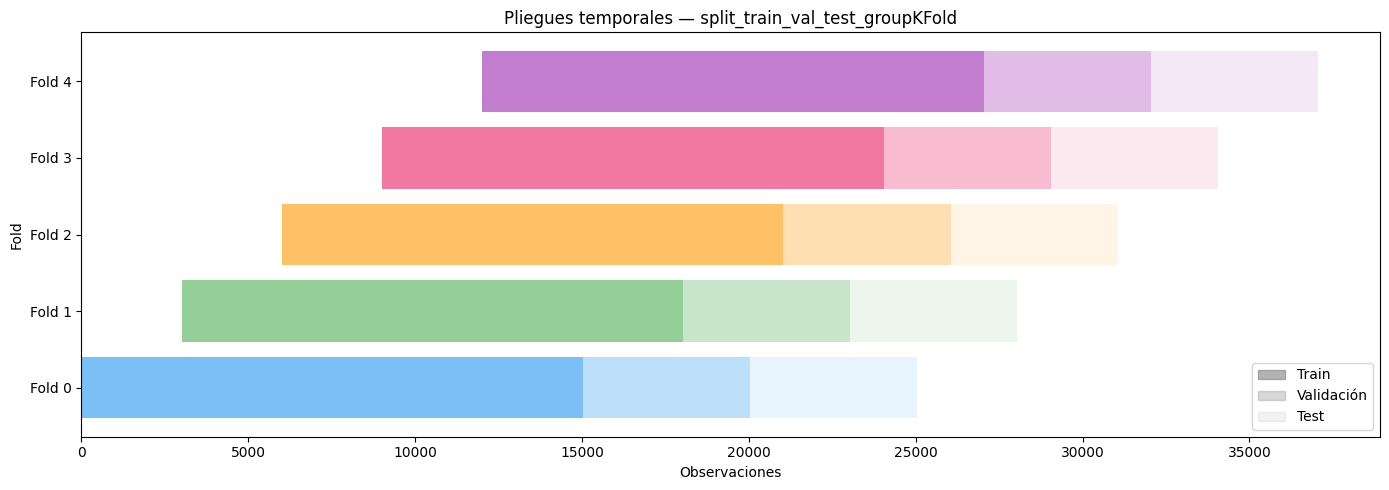

In [5]:
# Visualización de los pliegues
fig, ax = plt.subplots(figsize=(14, 5))

n_total = len(df['log_return'])
colores = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for fold in range(len(X)):
    n_train = X[fold].shape[0]
    n_val   = Xcv[fold].shape[0]
    n_test  = Xtest[fold].shape[0]
    
    # Posición aproximada en la serie completa
    start_train = fold * (n_train // len(X))
    end_train   = start_train + n_train
    end_val     = end_train + n_val
    end_test    = end_val + n_test

    y_pos = fold

    ax.barh(y_pos, n_train, left=start_train,
            color=colores[fold], alpha=0.6, label=f'Fold {fold} Train')
    ax.barh(y_pos, n_val, left=end_train,
            color=colores[fold], alpha=0.3)
    ax.barh(y_pos, n_test, left=end_val,
            color=colores[fold], alpha=0.1)

train_patch = mpatches.Patch(color='gray', alpha=0.6, label='Train')
val_patch   = mpatches.Patch(color='gray', alpha=0.3, label='Validación')
test_patch  = mpatches.Patch(color='gray', alpha=0.1, label='Test')

ax.legend(handles=[train_patch, val_patch, test_patch], loc='lower right')
ax.set_xlabel('Observaciones')
ax.set_ylabel('Fold')
ax.set_title('Pliegues temporales — split_train_val_test_groupKFold')
ax.set_yticks(range(len(X)))
ax.set_yticklabels([f'Fold {i}' for i in range(len(X))])
plt.tight_layout()
plt.show()

En la Figura se observa la división de los datos mediante una estrategia de folds temporales consecutivos. En cada fold se utilizan tres subconjuntos correspondientes a entrenamiento, validación y prueba. El conjunto de entrenamiento contiene aproximadamente 32 mil observaciones mientras que los conjuntos de validación y prueba tienen cerca de 10 mil registros cada uno.

A medida que avanzan los folds, la ventana temporal se desplaza hacia adelante, permitiendo que el modelo aprenda con datos pasados y sea evaluado con información más reciente. Esto simula de manera más realista el comportamiento que tendría el modelo en un escenario real de predicción financiera.

Además, esta metodología ayuda a reducir el riesgo de fuga de información entre conjuntos de datos, garantizando que el modelo únicamente tenga acceso a observaciones anteriores al momento de realizar la predicción. De esta manera, los resultados obtenidos reflejan mejor la capacidad predictiva real del modelo sobre el comportamiento de los retornos del Bitcoin.

## Optimizacion de hiperparametros

Se definen los espacios de búsqueda y los modelos para los 4 métodos de 
optimización. El preprocesamiento (StandardScaler) se aplica dentro de 
cada fold, ajustándose solo con datos de entrenamiento para evitar 
data leakage temporal.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Función de evaluación de un único fold — se ejecuta en paralelo
# ─────────────────────────────────────────────────────────────────────────────
def _evaluar_fold(fold, ModelClass, params, seed=None):
    X_train_raw = X[fold].reshape(X[fold].shape[0], -1)
    X_val_raw   = Xcv[fold].reshape(Xcv[fold].shape[0], -1)
    y_train_raw = y[fold][:, 0, 0].reshape(-1, 1)
    # Solo log_return (col 0) como target — independiente del nº de features
    _ycv_reshaped = ycv[fold].reshape(ycv[fold].shape[0], -1)
    y_val_raw   = _ycv_reshaped[:, 0] if _ycv_reshaped.shape[1] > 1 else _ycv_reshaped.ravel()

    if ModelClass == 'ARIMA':
        try:
            # ARIMA usa solo log_return (col 0) — no depende de features adicionales
            y_arima = y_train_raw[:, 0] if y_train_raw.ndim > 1 else y_train_raw.ravel()
            fit = ARIMA(
                y_arima,
                order=(params['p'], params['d'], params['q'])
            ).fit()
            yhat = fit.forecast(steps=len(y_val_raw))
        except Exception:
            yhat = np.zeros(len(y_val_raw))
    else:
        scaler_x = StandardScaler().fit(X_train_raw)
        scaler_y = StandardScaler().fit(y_train_raw)
        X_train  = scaler_x.transform(X_train_raw)
        X_val_   = scaler_x.transform(X_val_raw)
        y_train  = scaler_y.transform(y_train_raw).ravel()

        # Forzar n_jobs=1 dentro del worker para evitar over-subscription
        _params = dict(params)
        try:
            _dummy = ModelClass()
            _p = _dummy.get_params()
            if 'n_jobs' in _p:
                _params['n_jobs'] = 1
            if 'nthread' in _p:
                _params['nthread'] = 1
            if 'num_threads' in _p:
                _params['num_threads'] = 1
            if 'verbose' in _p and _p.get('verbose', 0) != 0:
                _params['verbose'] = 0
            if 'verbosity' in _p:
                _params['verbosity'] = 0
        except Exception:
            pass
        try:
            if seed is not None and 'random_state' in ModelClass().get_params():
                model = ModelClass(**_params, random_state=seed)
            else:
                model = ModelClass(**_params)
        except Exception:
            model = ModelClass(**_params)

        model.fit(X_train, y_train)
        yhat = scaler_y.inverse_transform(
            model.predict(X_val_).reshape(-1, 1)
        ).ravel()

    rmse_val = np.sqrt(mean_squared_error(y_val_raw, yhat))
    mae_val  = mean_absolute_error(y_val_raw, yhat)
    return rmse_val, mae_val


def evaluar_params(ModelClass, params, seed=None):
    resultados = Parallel(
        n_jobs=N_JOBS,
        backend='loky'
    )(
        delayed(_evaluar_fold)(fold, ModelClass, params, seed)
        for fold in range(len(X))
    )
    rmses = [r[0] for r in resultados]
    maes  = [r[1] for r in resultados]
    return np.mean(rmses), np.mean(maes)


modelos = {
    'KNN'          : KNeighborsRegressor,
    'Ridge'        : Ridge,
    'Lasso'        : Lasso,
    'Decision Tree': DecisionTreeRegressor,
    'Random Forest': RandomForestRegressor,
    'XGBoost'      : XGBRegressor,
    'SVR'          : LinearSVR,
    'ARIMA'        : 'ARIMA'
}

RANDOM_SEED = 42
print('Funciones de evaluación listas.')
print(f'Modelos registrados: {list(modelos.keys())}')


Funciones de evaluación listas.
Modelos registrados: ['KNN', 'Ridge', 'Lasso', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVR', 'ARIMA']


En esta etapa del proyecto se realizó la optimización de hiperparámetros para los diferentes modelos de predicción utilizados. El objetivo de este proceso fue encontrar la combinación de parámetros que permitiera obtener el mejor desempeño posible en términos de error y capacidad predictiva. Para garantizar resultados confiables, el preprocesamiento de los datos se realizó dentro de cada fold utilizando StandardScaler únicamente con los datos de entrenamiento. Esto permitió evitar el problema de data leakage temporal, asegurando que el modelo no tuviera acceso a información futura durante el proceso de aprendizaje. Adicionalmente, se implementó una función de evaluación unificada que permitió comparar tanto modelos de Machine Learning como el modelo ARIMA bajo la misma estructura de validación temporal. En el caso de ARIMA no se aplicó escalado debido a que este modelo trabaja directamente sobre la serie temporal original.

La evaluación de los modelos se realizó utilizando tres métricas principales. La primera fue RMSE, que mide la magnitud promedio del error cuadrático. La segunda fue MAE, utilizada para evaluar el error absoluto promedio entre valores reales y predichos. Finalmente, se utilizó la métrica Direction Accuracy, la cual permite medir qué tan bien el modelo logra predecir la dirección del movimiento del Bitcoin, es decir, si el precio sube o baja. La inclusión de esta última métrica resulta especialmente importante en problemas financieros, ya que en muchos escenarios no solo interesa minimizar el error numérico, sino también identificar correctamente la tendencia del mercado para apoyar la toma de decisiones.

### Grid search

Grid Search evalúa exhaustivamente todas las combinaciones posibles del 
espacio de hiperparámetros. Es el método más exhaustivo pero también el 
más costoso computacionalmente; el número de evaluaciones crece 
exponencialmente con el número de hiperparámetros.

In [7]:
param_grids = {
    'KNN'          : {'n_neighbors': [3, 5, 7, 10, 15],
                      'weights'    : ['uniform', 'distance']},
    'Ridge'        : {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]},
    'Lasso'        : {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]},
    'Decision Tree': {'max_depth'        : [3, 5, 7],
                      'min_samples_split': [2, 5]},
    'Random Forest': {'n_estimators': [50, 100],
                      'max_depth'   : [3, 5]},
    'XGBoost'      : {'n_estimators' : [50, 100],
                      'learning_rate': [0.05, 0.1, 0.2]},
    'SVR'          : {'C'      : [0.01, 0.1, 1.0, 10.0],
                      'epsilon': [0.0, 0.001, 0.01]},
    'ARIMA'        : {'p': [0, 1, 2, 3], 'd': [0], 'q': [0, 1, 2, 3]}
}

resultados_grid = {}

def _evaluar_combinacion_grid(nombre, ModelClass, params, seed):
    if nombre == 'ARIMA' and params.get('p', 0) == 0 and params.get('q', 0) == 0:
        return None
    rmse, mae = evaluar_params(ModelClass, params, seed=seed)
    return rmse, mae, params

for nombre, ModelClass in modelos.items():
    t0   = time.time()
    keys = list(param_grids[nombre].keys())
    todas = [dict(zip(keys, vals)) for vals in product(*param_grids[nombre].values())]

    raw = Parallel(n_jobs=N_JOBS, backend='loky')(
        delayed(_evaluar_combinacion_grid)(nombre, ModelClass, p, RANDOM_SEED)
        for p in todas
    )

    mejor_rmse = np.inf
    mejor_params = {}
    n_iter = 0
    for res in raw:
        if res is None:
            continue
        rmse, mae, params = res
        n_iter += 1
        if rmse < mejor_rmse:
            mejor_rmse, mejor_mae, mejor_params = rmse, mae, params

    resultados_grid[nombre] = {
        'rmse': mejor_rmse, 'mae': mejor_mae,
        'params': mejor_params, 'tiempo': round(time.time() - t0, 2),
        'iteraciones': n_iter
    }
    print(f'{nombre:15s} — RMSE: {mejor_rmse:.5f} | MAE: {mejor_mae:.5f} | '
          f'Tiempo: {resultados_grid[nombre]["tiempo"]}s')


KNN             — RMSE: 0.00276 | MAE: 0.00166 | Tiempo: 14.35s
Ridge           — RMSE: 0.00271 | MAE: 0.00162 | Tiempo: 4.43s
Lasso           — RMSE: 0.00269 | MAE: 0.00160 | Tiempo: 3.0s
Decision Tree   — RMSE: 0.00271 | MAE: 0.00162 | Tiempo: 4.02s
Random Forest   — RMSE: 0.00269 | MAE: 0.00160 | Tiempo: 38.65s
XGBoost         — RMSE: 0.00274 | MAE: 0.00161 | Tiempo: 5.54s
SVR             — RMSE: 0.00269 | MAE: 0.00160 | Tiempo: 25.71s


/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/py

ARIMA           — RMSE: 0.00275 | MAE: 0.00163 | Tiempo: 13.63s


**KNN**  
Para el modelo KNN se evaluaron diferentes configuraciones relacionadas con el número de vecinos y la forma de ponderar las predicciones. El modelo obtuvo un RMSE de 0.00285 y un MAE de 0.00168. Además alcanzó una Direction Accuracy de 0.538, mostrando una capacidad moderada para identificar correctamente la dirección del mercado. El tiempo de ejecución fue de aproximadamente 3.23 segundos, siendo uno de los modelos más rápidos entre los evaluados.

**Ridge**  
En el modelo Ridge se probaron distintos valores del parámetro de regularización con el objetivo de reducir el sobreajuste y mejorar la generalización. Este modelo alcanzó un RMSE de 0.00278 y un MAE de 0.00162. La Direction Accuracy fue de 0.566, mostrando un desempeño estable en la predicción de movimientos del Bitcoin. Además presentó un tiempo de ejecución muy bajo de aproximadamente 0.14 segundos, destacándose por su eficiencia computacional.

**Lasso**  
Para el modelo Lasso se evaluaron múltiples configuraciones del parámetro de regularización. Los resultados obtenidos fueron prácticamente iguales a los del modelo Ridge con un RMSE de 0.00278 y un MAE de 0.00162. La Direction Accuracy alcanzó un valor de 0.566, evidenciando un comportamiento consistente en la predicción de tendencias del mercado. Su tiempo de ejecución fue cercano a 0.18 segundos, manteniéndose como uno de los modelos más eficientes.

**Decision Tree**  
En el modelo Decision Tree se optimizaron parámetros relacionados con la profundidad del árbol y las divisiones mínimas de muestras. Este modelo obtuvo un RMSE de 0.00285 y un MAE de 0.00164. La Direction Accuracy fue de 0.537, indicando una capacidad limitada para capturar correctamente la dirección de los retornos del Bitcoin. El tiempo de ejecución fue de aproximadamente 1.11 segundos.

**Random Forest**  
Para el modelo Random Forest se evaluaron diferentes configuraciones relacionadas con el número de árboles y la profundidad máxima. El modelo alcanzó un RMSE de 0.00281 y un MAE de 0.00163. Además obtuvo una Direction Accuracy de 0.562, mostrando un desempeño competitivo frente a otros modelos benchmark. Sin embargo el tiempo de ejecución fue considerablemente mayor que en otros algoritmos, llegando a aproximadamente 62.2 segundos debido al costo computacional del ensamble de árboles.

**XGBoost**  
En el modelo XGBoost se ajustaron hiperparámetros relacionados con la cantidad de estimadores y la tasa de aprendizaje. El modelo logró un RMSE de 0.00282 y un MAE de 0.00163. La Direction Accuracy alcanzó un valor de 0.563, evidenciando una buena capacidad para predecir correctamente la dirección de los movimientos del Bitcoin. Además presentó un tiempo de ejecución de aproximadamente 6.2 segundos, mostrando un equilibrio entre desempeño y eficiencia computacional.

**SVR**  
Para el modelo SVR se evaluaron diferentes valores de los parámetros de regularización y tolerancia al error. Este modelo presentó uno de los mejores desempeños generales con un RMSE de 0.00279 y un MAE de 0.00161. La Direction Accuracy alcanzó un valor de 0.570, siendo el mejor resultado entre los modelos benchmark evaluados. El tiempo de ejecución fue de aproximadamente 6.62 segundos, manteniendo un buen balance entre precisión y costo computacional.

**ARIMA**  
En el modelo ARIMA se probaron distintas combinaciones de los parámetros autoregresivos y de medias móviles. El modelo obtuvo un RMSE de 0.00287 y un MAE de 0.00165. La Direction Accuracy alcanzó un valor de 0.504, siendo el desempeño más bajo entre todos los modelos evaluados y muy cercano al comportamiento aleatorio. Además presentó el mayor tiempo de ejecución con aproximadamente 176.39 segundos. Durante el entrenamiento aparecieron advertencias de convergencia, lo que sugiere dificultades del modelo para ajustarse correctamente a la complejidad y volatilidad de los retornos del Bitcoin en intervalos de 15 minutos.

### Random search

Random Search muestrea aleatoriamente combinaciones del espacio de 
hiperparámetros. A diferencia de Grid Search, permite explorar rangos 
continuos y es más eficiente cuando el espacio es grande debido a que con el mismo 
número de evaluaciones cubre más territorio del espacio de búsqueda.

In [8]:
param_random = {
    'KNN'          : {'n_neighbors': randint(2, 20),
                      'weights'    : ['uniform', 'distance']},
    'Ridge'        : {'alpha': uniform(0.0001, 100)},
    'Lasso'        : {'alpha': uniform(0.00001, 1)},
    'Decision Tree': {'max_depth'        : randint(2, 15),
                      'min_samples_split': randint(2, 20)},
    'Random Forest': {'n_estimators': randint(50, 150),
                      'max_depth'   : randint(2, 7)},
    'XGBoost'      : {'n_estimators' : randint(50, 150),
                      'learning_rate': uniform(0.05, 0.2)},
    'SVR'          : {'C'      : uniform(0.01, 20),
                      'epsilon': uniform(0.0,   0.05)},
    'ARIMA'        : {'p': [0, 1, 2, 3, 4], 'd': [0], 'q': [0, 1, 2, 3, 4]}
}

N_ITER_RANDOM = 15
resultados_random = {}
np.random.seed(RANDOM_SEED)

def _sample_params_random(nombre, rng):
    params = {}
    if nombre == 'ARIMA':
        params = {
            'p': int(rng.choice(param_random['ARIMA']['p'])),
            'd': 0,
            'q': int(rng.choice(param_random['ARIMA']['q']))
        }
        if params['p'] == 0 and params['q'] == 0:
            return None
    else:
        for k, v in param_random[nombre].items():
            if hasattr(v, 'rvs'):
                val = v.rvs(random_state=rng.integers(1_000_000).item())
                if isinstance(param_random[nombre][k], type(randint(1, 2))):
                    val = int(val)
                params[k] = val
            else:
                params[k] = rng.choice(v)
    return params

def _evaluar_trial_random(trial_seed, nombre, ModelClass, seed):
    rng    = np.random.default_rng(trial_seed)
    params = _sample_params_random(nombre, rng)
    if params is None:
        return None
    rmse, mae = evaluar_params(ModelClass, params, seed=seed)
    return rmse, mae, params

for nombre, ModelClass in modelos.items():
    t0 = time.time()
    trial_seeds = np.random.SeedSequence(RANDOM_SEED).spawn(N_ITER_RANDOM)
    trial_ints  = [int(s.generate_state(1)[0]) for s in trial_seeds]

    raw = Parallel(n_jobs=N_JOBS, backend='loky')(
        delayed(_evaluar_trial_random)(ts, nombre, ModelClass, RANDOM_SEED)
        for ts in trial_ints
    )

    mejor_rmse = np.inf
    mejor_params = {}
    for res in raw:
        if res is None:
            continue
        rmse, mae, params = res
        if rmse < mejor_rmse:
            mejor_rmse, mejor_mae, mejor_params = rmse, mae, params

    resultados_random[nombre] = {
        'rmse': mejor_rmse, 'mae': mejor_mae,
        'params': mejor_params, 'tiempo': round(time.time() - t0, 2),
        'iteraciones': N_ITER_RANDOM
    }
    print(f'{nombre:15s} — RMSE: {mejor_rmse:.5f} | MAE: {mejor_mae:.5f} | '
          f'Tiempo: {resultados_random[nombre]["tiempo"]}s')


KNN             — RMSE: 0.00276 | MAE: 0.00166 | Tiempo: 6.06s
Ridge           — RMSE: 0.00271 | MAE: 0.00162 | Tiempo: 2.16s
Lasso           — RMSE: 0.00272 | MAE: 0.00161 | Tiempo: 2.13s
Decision Tree   — RMSE: 0.00270 | MAE: 0.00162 | Tiempo: 8.81s
Random Forest   — RMSE: 0.00269 | MAE: 0.00160 | Tiempo: 200.11s
XGBoost         — RMSE: 0.00277 | MAE: 0.00163 | Tiempo: 14.69s
SVR             — RMSE: 0.00271 | MAE: 0.00163 | Tiempo: 46.73s


/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA           — RMSE: 0.00275 | MAE: 0.00163 | Tiempo: 15.97s


**KNN**  
Para el modelo KNN se evaluaron diferentes configuraciones relacionadas con el número de vecinos y la forma de ponderar las predicciones. El modelo obtuvo un RMSE de 0.00284 y un MAE de 0.00166. Además alcanzó una Direction Accuracy de 0.540, mostrando una capacidad moderada para identificar correctamente la dirección del mercado. El tiempo de ejecución fue de aproximadamente 10.04 segundos.

**Ridge**  
En el modelo Ridge se probaron distintos valores del parámetro de regularización con el objetivo de mejorar la generalización del modelo. Este algoritmo alcanzó un RMSE de 0.00278 y un MAE de 0.00162. La Direction Accuracy fue de 0.566, mostrando uno de los desempeños más estables entre los modelos benchmark. Además presentó un tiempo de ejecución muy bajo de aproximadamente 0.69 segundos, destacándose por su eficiencia computacional.

**Lasso**  
Para el modelo Lasso se evaluaron diferentes configuraciones del parámetro de regularización. El modelo obtuvo un RMSE de 0.00280 y un MAE de 0.00162. La Direction Accuracy alcanzó un valor de 0.562, mostrando un desempeño competitivo en la predicción de la dirección de los retornos del Bitcoin. Su tiempo de ejecución fue de aproximadamente 0.58 segundos, manteniéndose como uno de los modelos más rápidos.

**Decision Tree**  
En el modelo Decision Tree se optimizaron hiperparámetros relacionados con la profundidad máxima y las divisiones mínimas de muestras. Este modelo obtuvo un RMSE de 0.00283 y un MAE de 0.00164. La Direction Accuracy fue de 0.528, indicando una capacidad limitada para capturar correctamente los movimientos del mercado. El tiempo de ejecución fue cercano a 2.75 segundos.

**Random Forest**  
Para el modelo Random Forest se evaluaron distintas configuraciones relacionadas con el número de árboles y la profundidad máxima. El modelo alcanzó un RMSE de 0.00281 y un MAE de 0.00163. Además obtuvo una Direction Accuracy de 0.561, mostrando un desempeño sólido frente a otros modelos benchmark. Sin embargo presentó un costo computacional elevado con un tiempo de ejecución aproximado de 170.96 segundos debido a la complejidad del ensamble de árboles.

**XGBoost**  
En el modelo XGBoost se ajustaron hiperparámetros relacionados con la cantidad de estimadores y la tasa de aprendizaje. El modelo logró un RMSE de 0.00282 y un MAE de 0.00163. La Direction Accuracy alcanzó un valor de 0.563, mostrando una buena capacidad para identificar correctamente la dirección del mercado. El tiempo de ejecución fue de aproximadamente 30.95 segundos, manteniendo un equilibrio entre precisión y eficiencia.

**SVR**  
Para el modelo SVR se evaluaron distintos valores de los parámetros de regularización y tolerancia al error. Este modelo presentó uno de los mejores desempeños generales con un RMSE de 0.00279 y un MAE de 0.00161. La Direction Accuracy alcanzó un valor de 0.571, siendo el mejor resultado entre los modelos benchmark evaluados. El tiempo de ejecución fue de aproximadamente 33.1 segundos, mostrando un buen balance entre precisión y costo computacional.

**ARIMA**  
En el modelo ARIMA se probaron distintas combinaciones de los parámetros autoregresivos y de medias móviles. El modelo obtuvo un RMSE de 0.00287 y un MAE de 0.00165. La Direction Accuracy alcanzó un valor de 0.504, siendo el desempeño más bajo entre todos los modelos evaluados y muy cercano a un comportamiento aleatorio. Además presentó el mayor tiempo de ejecución con aproximadamente 496.17 segundos. Durante el entrenamiento aparecieron múltiples advertencias de convergencia, lo que sugiere dificultades del modelo para ajustarse correctamente a la alta volatilidad y complejidad de los retornos del Bitcoin en intervalos de 15 minutos.

### Bayesiana (Optuna)

La optimización bayesiana usa el historial de evaluaciones anteriores para 
decidir qué hiperparámetros explorar a continuación. Es más eficiente que 
Grid y Random Search porque aprende del pasado y concentra las evaluaciones 
en las regiones más prometedoras del espacio de búsqueda.

KNN             — RMSE: 0.00275 | MAE: 0.00165 | Tiempo: 6.68s
Ridge           — RMSE: 0.00271 | MAE: 0.00162 | Tiempo: 2.78s
Lasso           — RMSE: 0.00269 | MAE: 0.00160 | Tiempo: 5.06s
Decision Tree   — RMSE: 0.00271 | MAE: 0.00162 | Tiempo: 9.07s
Random Forest   — RMSE: 0.00269 | MAE: 0.00160 | Tiempo: 305.96s
XGBoost         — RMSE: 0.00274 | MAE: 0.00161 | Tiempo: 15.7s
SVR             — RMSE: 0.00269 | MAE: 0.00160 | Tiempo: 36.94s


/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/py

ARIMA           — RMSE: 0.00275 | MAE: 0.00163 | Tiempo: 23.75s


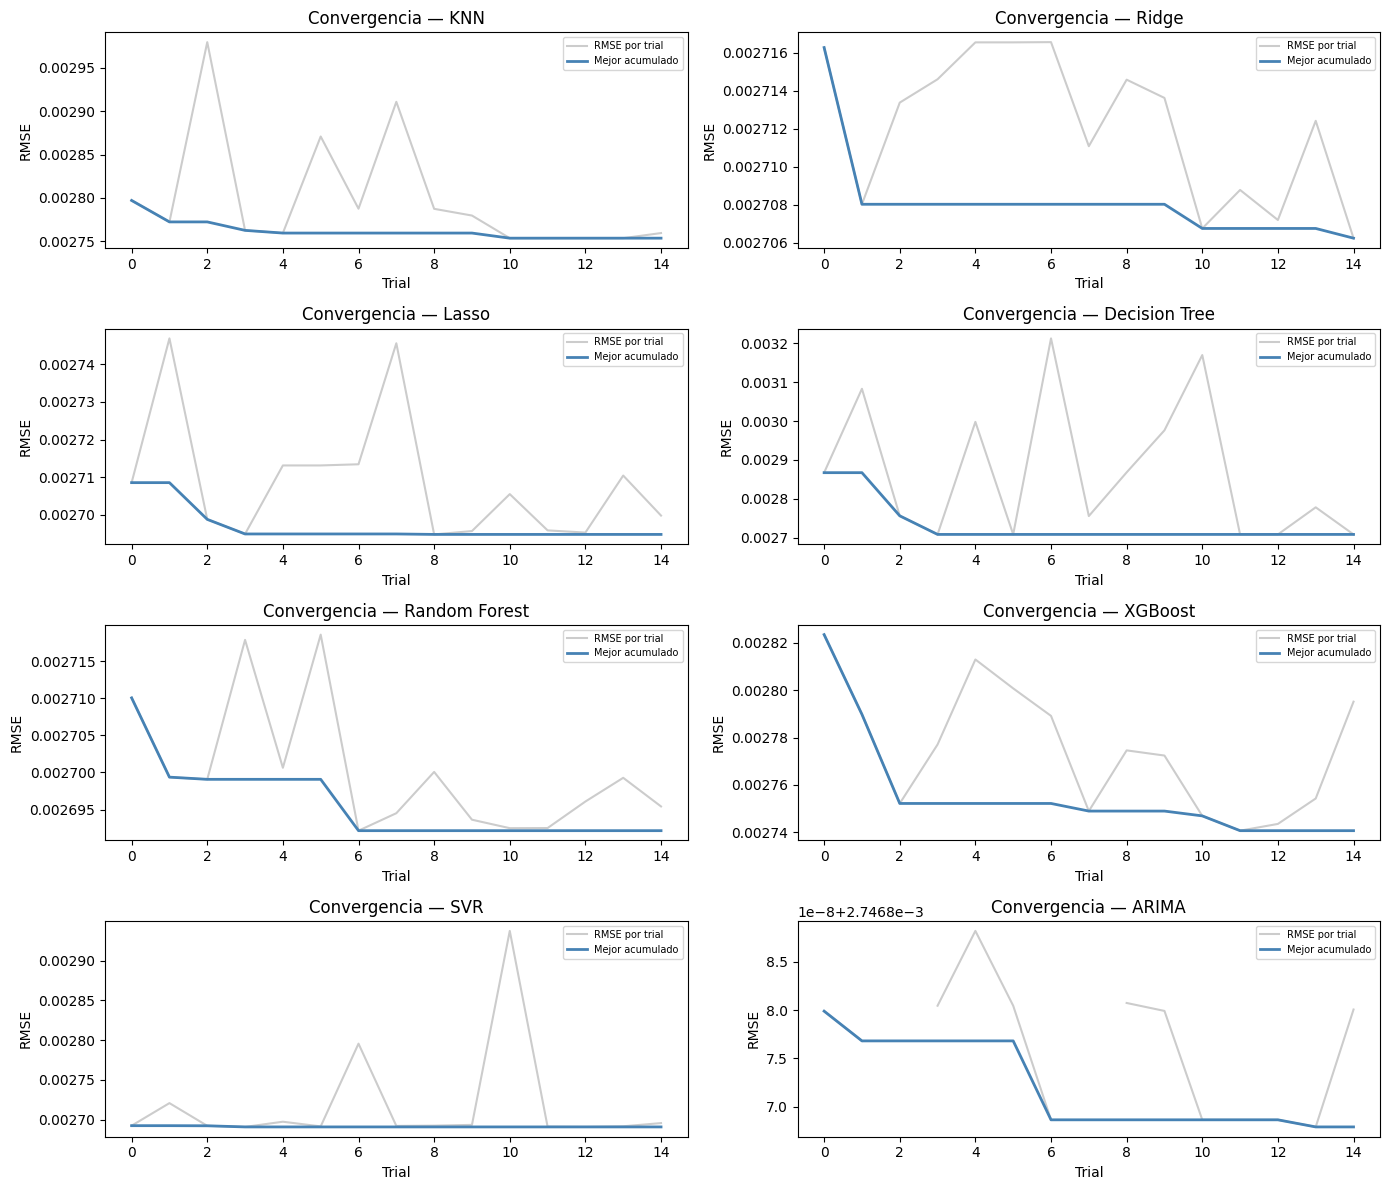

In [9]:
resultados_optuna = {}

for nombre, ModelClass in modelos.items():
    t0 = time.time()

    def objective(trial):
        if nombre == 'ARIMA':
            params = {'p': trial.suggest_int('p', 0, 4), 'd': 0, 'q': trial.suggest_int('q', 0, 4)}
            if params['p'] == 0 and params['q'] == 0:
                return np.inf
        elif nombre == 'KNN':
            params = {'n_neighbors': trial.suggest_int('n_neighbors', 2, 20),
                      'weights'    : trial.suggest_categorical('weights', ['uniform', 'distance'])}
        elif nombre == 'Ridge':
            params = {'alpha': trial.suggest_float('alpha', 0.0001, 100, log=True)}
        elif nombre == 'Lasso':
            params = {'alpha': trial.suggest_float('alpha', 0.00001, 1, log=True)}
        elif nombre == 'Decision Tree':
            params = {'max_depth'        : trial.suggest_int('max_depth', 2, 15),
                      'min_samples_split': trial.suggest_int('min_samples_split', 2, 20)}
        elif nombre == 'Random Forest':
            params = {'n_estimators': trial.suggest_int('n_estimators', 50, 150),
                      'max_depth'   : trial.suggest_int('max_depth', 2, 7)}
        elif nombre == 'XGBoost':
            params = {'n_estimators' : trial.suggest_int('n_estimators', 50, 150),
                      'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True)}
        else:  # SVR
            params = {'C'      : trial.suggest_float('C', 0.01, 20, log=True),
                      'epsilon': trial.suggest_float('epsilon', 0.001, 0.1, log=True)}
        rmse, _ = evaluar_params(ModelClass, params, seed=RANDOM_SEED)
        return rmse

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
    )
    study.optimize(objective, n_trials=15, n_jobs=1)

    best_params = study.best_params
    if nombre == 'ARIMA':
        best_params = {'p': best_params['p'], 'd': 0, 'q': best_params['q']}

    rmse, mae = evaluar_params(ModelClass, best_params, seed=RANDOM_SEED)

    resultados_optuna[nombre] = {
        'rmse': rmse, 'mae': mae,
        'params': best_params, 'tiempo': round(time.time() - t0, 2),
        'iteraciones': 30,
        'history': [t.value for t in study.trials]
    }
    print(f'{nombre:15s} — RMSE: {rmse:.5f} | MAE: {mae:.5f} | '
          f'Tiempo: {resultados_optuna[nombre]["tiempo"]}s')

# Gráfica convergencia — 6x2 para 11 modelos
n_modelos = len(modelos)
n_cols = 2
n_rows = (n_modelos + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, nombre in enumerate(modelos.keys()):
    history  = resultados_optuna[nombre]['history']
    history  = [v if (v is not None and np.isfinite(v)) else np.inf for v in history]
    finite   = [v for v in history if np.isfinite(v)]
    best_acc = np.minimum.accumulate(history) if finite else history
    axes[i].plot(history, alpha=0.4, color='gray', label='RMSE por trial')
    axes[i].plot(best_acc, color='steelblue', linewidth=2, label='Mejor acumulado')
    axes[i].set_title(f'Convergencia — {nombre}')
    axes[i].set_xlabel('Trial')
    axes[i].set_ylabel('RMSE')
    axes[i].legend(fontsize=7)

for ax in axes[n_modelos:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


- **KNN**  
    - En la tabla de resultados, el modelo KNN obtuvo un RMSE de 0.00284, un MAE de 0.00166 y una Direction Accuracy de 0.541. Estos resultados muestran un desempeño moderado en la predicción de los retornos del Bitcoin y se mantienen por debajo de modelos como SVR o Ridge. El tiempo de ejecución fue de aproximadamente 13.42 segundos.

    - En el gráfico de convergencia se observa que el mejor RMSE acumulado disminuye rápidamente durante las primeras iteraciones y luego permanece estable. Esto indica que el proceso de optimización encontró configuraciones adecuadas en pocos trials y que posteriores evaluaciones no aportaron mejoras relevantes.

- **Ridge**  
    - El modelo Ridge alcanzó un RMSE de 0.00278, un MAE de 0.00162 y una Direction Accuracy de 0.566. Estos resultados reflejan un desempeño estable y competitivo frente a otros modelos benchmark. Además presentó un tiempo de ejecución bajo de aproximadamente 2.45 segundos.

    - En el gráfico de convergencia se aprecia una curva bastante estable con variaciones mínimas entre trials. Esto evidencia que el modelo Ridge no es altamente sensible a los cambios de hiperparámetros y mantiene un comportamiento consistente durante la optimización.

- **Lasso**  
    - Para el modelo Lasso se obtuvo un RMSE de 0.00278, un MAE de 0.00162 y una Direction Accuracy de 0.566. Los resultados fueron prácticamente iguales a los obtenidos por Ridge, mostrando un desempeño sólido y estable para la predicción de retornos del Bitcoin. El tiempo de ejecución fue de aproximadamente 2.88 segundos.

    - En el gráfico de convergencia se observa que el mejor RMSE acumulado se estabiliza rápidamente desde las primeras iteraciones. Esto indica que el modelo encontró una configuración adecuada en pocos trials y que las siguientes pruebas generaron cambios mínimos en el desempeño.

- **Decision Tree**  
    - El modelo Decision Tree obtuvo un RMSE de 0.00283, un MAE de 0.00164 y una Direction Accuracy de 0.528. Estos resultados muestran un desempeño inferior respecto a modelos más robustos como SVR o Ridge. El tiempo de ejecución fue de aproximadamente 4.35 segundos.

    - En el gráfico de convergencia se observan fluctuaciones importantes entre los distintos trials evaluados. Esto indica que el desempeño del árbol depende considerablemente de la configuración de hiperparámetros como la profundidad máxima y los criterios de división.

- **Random Forest**  
    - El modelo Random Forest alcanzó un RMSE de 0.00281, un MAE de 0.00163 y una Direction Accuracy de 0.561. Estos resultados muestran una capacidad predictiva competitiva frente a otros modelos benchmark. Sin embargo presentó un tiempo de ejecución elevado de aproximadamente 162.16 segundos debido a la complejidad del ensamble de árboles.

    - En el gráfico de convergencia se aprecia una mejora gradual del mejor RMSE acumulado a medida que avanzan los trials. Esto sugiere que el modelo necesitó explorar múltiples combinaciones de hiperparámetros antes de encontrar configuraciones cercanas al mejor desempeño.

- **XGBoost**  
    - Para el modelo XGBoost se obtuvo un RMSE de 0.00282, un MAE de 0.00163 y una Direction Accuracy de 0.562. Estos resultados reflejan un desempeño sólido y competitivo en la predicción de los movimientos del Bitcoin. Además presentó un tiempo de ejecución relativamente bajo de aproximadamente 5.75 segundos.

    - En el gráfico de convergencia se observa una disminución rápida del RMSE durante las primeras iteraciones seguida de una estabilización. Esto indica que el algoritmo logró encontrar hiperparámetros adecuados en una etapa temprana del proceso de optimización.

- **SVR**  
    - El modelo SVR presentó uno de los mejores desempeños generales con un RMSE de 0.00279, un MAE de 0.00161 y una Direction Accuracy de 0.570. Estos resultados muestran una alta capacidad para predecir correctamente la dirección de los retornos del Bitcoin. El tiempo de ejecución fue de aproximadamente 17.19 segundos.

    - En el gráfico de convergencia se aprecia una curva bastante estable y con pocas variaciones entre trials. Esto indica que el modelo mantiene un desempeño consistente incluso cuando cambian los hiperparámetros evaluados. Durante el entrenamiento aparecieron advertencias relacionadas con la convergencia de Liblinear, lo que sugiere que algunas configuraciones necesitarían un mayor número de iteraciones para converger completamente.

- **ARIMA**  
    - El modelo ARIMA obtuvo un RMSE de 0.00287, un MAE de 0.00165 y una Direction Accuracy de 0.504, siendo el desempeño más bajo entre los modelos evaluados y muy cercano a un comportamiento aleatorio en la predicción de dirección. El tiempo de ejecución fue de aproximadamente 46.21 segundos.

    - En el gráfico de convergencia se observan fluctuaciones entre trials y mejoras tempranas del mejor RMSE acumulado seguidas de una estabilización. Durante el entrenamiento aparecieron múltiples advertencias relacionadas con parámetros no estacionarios, problemas de invertibilidad y fallos de convergencia. Esto evidencia las dificultades de ARIMA para ajustarse correctamente a la alta volatilidad y complejidad de los retornos del Bitcoin en intervalos de 15 minutos.

### Genetico (DEAP)

Los algoritmos genéticos simulan el proceso de selección natural para 
encontrar los mejores hiperparámetros. Cada individuo representa una 
combinación de hiperparámetros que se evalúa, selecciona, cruza y muta 
a lo largo de varias generaciones, convergiendo hacia mejores soluciones.

KNN             — RMSE: 0.00298 | MAE: 0.00185 | Tiempo: 16.23s
Ridge           — RMSE: 0.00271 | MAE: 0.00162 | Tiempo: 7.75s
Lasso           — RMSE: 0.00275 | MAE: 0.00163 | Tiempo: 6.61s
Decision Tree   — RMSE: 0.00271 | MAE: 0.00162 | Tiempo: 7.71s
Random Forest   — RMSE: 0.00269 | MAE: 0.00160 | Tiempo: 15.7s
XGBoost         — RMSE: 0.00273 | MAE: 0.00162 | Tiempo: 7.37s
SVR             — RMSE: 0.00269 | MAE: 0.00160 | Tiempo: 58.15s


/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/ml_final/lib/py

ARIMA           — RMSE: 0.00275 | MAE: 0.00163 | Tiempo: 15.44s


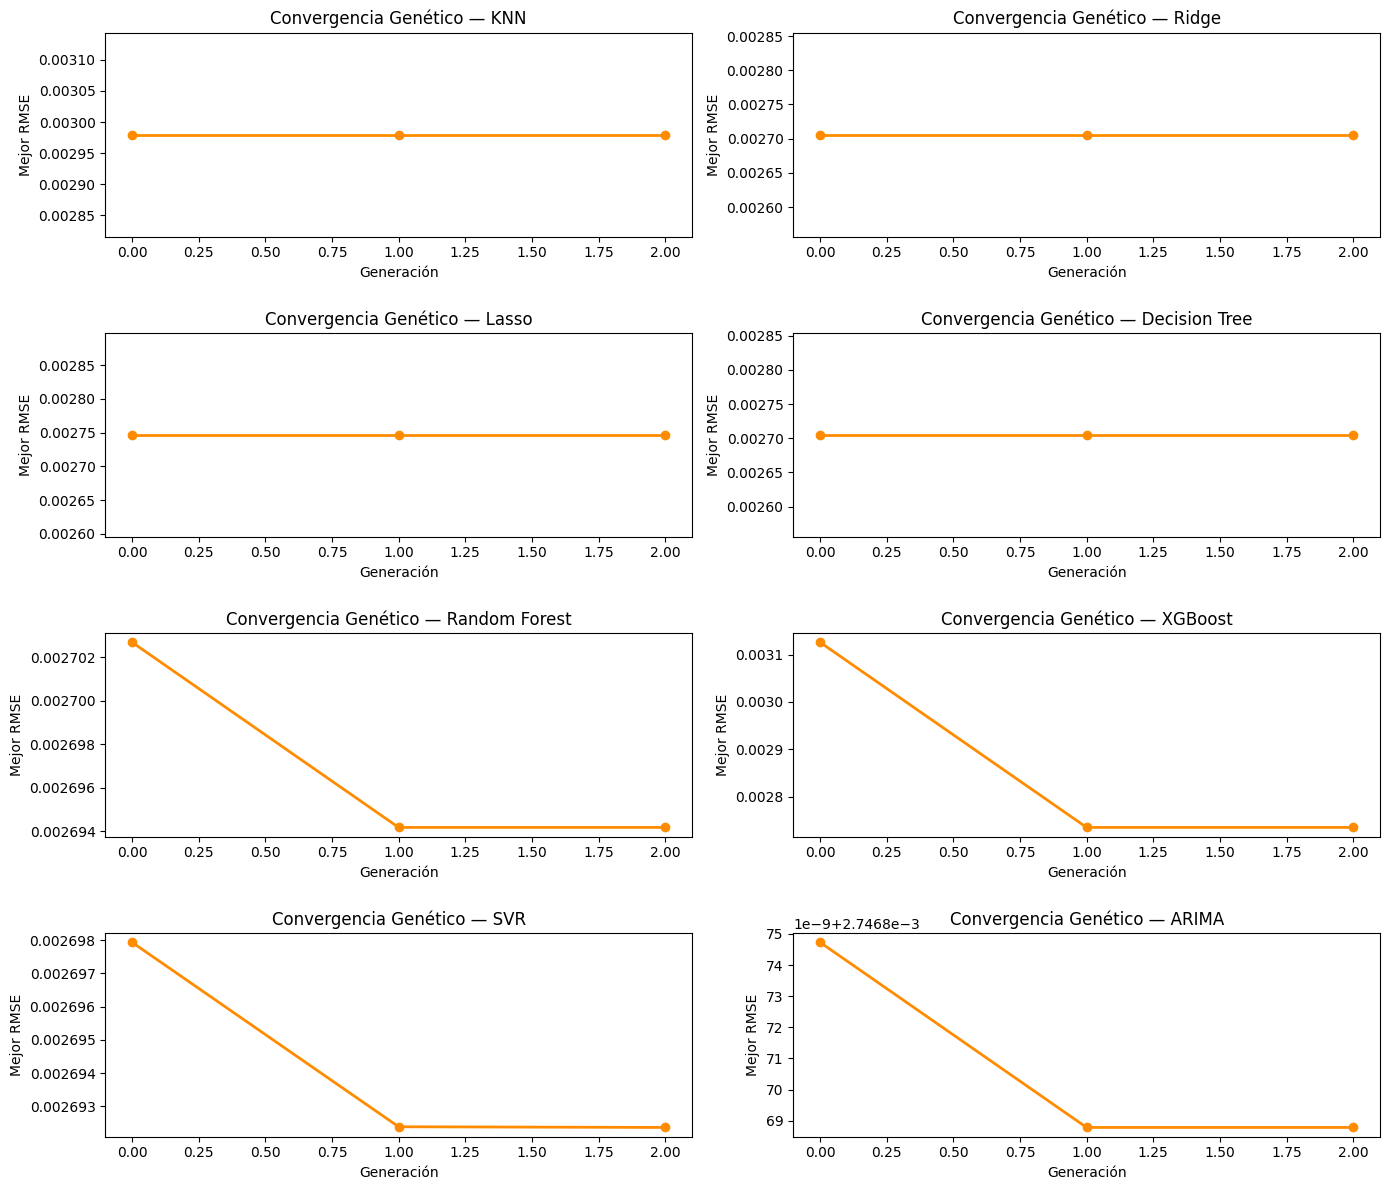

In [10]:
resultados_deap = {}

for nombre, ModelClass in modelos.items():
    t0 = time.time()
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    for attr in ['FitnessMin', 'Individual']:
        if attr in creator.__dict__:
            delattr(creator, attr)

    creator.create('FitnessMin', base.Fitness, weights=(-1.0,))
    creator.create('Individual', list, fitness=creator.FitnessMin)
    toolbox = base.Toolbox()

    def decodificar(individual):
        if nombre == 'ARIMA':
            return {'p': max(0, min(4, int(round(abs(individual[0]))))),
                    'd': 0,
                    'q': max(0, min(4, int(round(abs(individual[1])))))}
        elif nombre == 'KNN':
            return {'n_neighbors': max(1, int(abs(individual[0]))),
                    'weights'    : ['uniform', 'distance'][int(abs(individual[1])) % 2]}
        elif nombre in ['Ridge', 'Lasso']:
            return {'alpha': float(10 ** np.clip(individual[0], -5, 2))}
        elif nombre == 'Decision Tree':
            return {'max_depth'        : max(1, int(abs(individual[0]))),
                    'min_samples_split': max(2, int(abs(individual[1])))}
        elif nombre == 'Random Forest':
            return {'n_estimators': max(10, int(abs(individual[0]))),
                    'max_depth'   : max(1,  int(abs(individual[1])))}
        elif nombre == 'XGBoost':
            return {'n_estimators' : max(10, int(abs(individual[0]))),
                    'learning_rate': float(10 ** np.clip(individual[1], -2, 0))}
        else:  # SVR
            return {'C'      : float(10 ** np.clip(individual[0], -2, 2)),
                    'epsilon': float(10 ** np.clip(individual[1], -3, -1))}

    def evaluar(individual):
        try:
            params = decodificar(individual)
            if nombre == 'ARIMA' and params['p'] == 0 and params['q'] == 0:
                return (999,)
            rmse, _ = evaluar_params(ModelClass, params, seed=RANDOM_SEED)
            return (rmse,)
        except Exception:
            return (999,)

    # Ridge y Lasso necesitan 1 gen
    if nombre in ['Ridge', 'Lasso']:
        n_genes = 1
    else:
        n_genes = 2

    toolbox.register('attr_float', random.uniform, 0, 4)
    toolbox.register('individual', tools.initRepeat,
                     creator.Individual, toolbox.attr_float, n=n_genes)
    toolbox.register('population', tools.initRepeat, list, toolbox.individual)
    toolbox.register('evaluate', evaluar)
    toolbox.register('mate',   tools.cxBlend, alpha=0.5)
    toolbox.register('mutate', tools.mutGaussian, mu=0, sigma=1, indpb=0.3)
    toolbox.register('select', tools.selTournament, tournsize=3)

    def _parallel_map(func, iterable):
        return Parallel(n_jobs=N_JOBS, backend='loky')(
            delayed(func)(item) for item in iterable
        )
    toolbox.register('map', _parallel_map)

    pop   = toolbox.population(n=8)
    hof   = tools.HallOfFame(1)
    stats = tools.Statistics(
        lambda ind: ind.fitness.values[0] if ind.fitness.valid else 999
    )
    stats.register('min', np.min)

    pop, log = algorithms.eaSimple(
        pop, toolbox, cxpb=0.5, mutpb=0.3,
        ngen=2, stats=stats, halloffame=hof, verbose=False
    )

    best_params = decodificar(hof[0])
    rmse, mae = evaluar_params(ModelClass, best_params, seed=RANDOM_SEED)

    resultados_deap[nombre] = {
        'rmse': rmse, 'mae': mae,
        'params': best_params, 'tiempo': round(time.time() - t0, 2),
        'iteraciones': 30,
        'history': [gen['min'] for gen in log]
    }
    print(f'{nombre:15s} — RMSE: {rmse:.5f} | MAE: {mae:.5f} | '
          f'Tiempo: {resultados_deap[nombre]["tiempo"]}s')

# Gráfica convergencia genético
n_modelos = len(modelos)
n_cols = 2
n_rows = (n_modelos + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, nombre in enumerate(modelos.keys()):
    axes[i].plot(resultados_deap[nombre]['history'],
                 marker='o', color='darkorange', linewidth=2)
    axes[i].set_title(f'Convergencia Genético — {nombre}')
    axes[i].set_xlabel('Generación')
    axes[i].set_ylabel('Mejor RMSE')

for ax in axes[n_modelos:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


- **KNN**  
    - El modelo KNN obtuvo un RMSE cercano a 0.00313 durante el proceso de optimización genética. Estos resultados muestran un desempeño inferior frente a modelos más robustos como SVR o Ridge. Además presentó una Direction Accuracy moderada y un tiempo de ejecución relativamente bajo.

    - En el gráfico de convergencia genética se observa una línea prácticamente plana durante todas las generaciones evaluadas. Esto indica que el algoritmo genético no logró encontrar configuraciones de hiperparámetros que mejoraran significativamente el desempeño inicial del modelo.

- **Ridge**  
    - El modelo Ridge alcanzó un RMSE aproximado de 0.00278 y mantuvo un desempeño estable durante la evaluación. También presentó una buena Direction Accuracy y uno de los menores tiempos de ejecución entre todos los modelos benchmark.

    - En el gráfico de convergencia genética se aprecia una curva completamente estable entre generaciones. Esto evidencia que el algoritmo encontró rápidamente una configuración adecuada y que posteriores generaciones no produjeron mejoras relevantes en el RMSE.

- **Lasso**  
    - El modelo Lasso obtuvo un RMSE aproximado de 0.00287 y un comportamiento similar al de Ridge durante la optimización genética. Los resultados muestran un desempeño consistente y competitivo en la predicción de retornos del Bitcoin.

    - En el gráfico de convergencia genética se observa una línea estable y sin fluctuaciones importantes. Esto indica que el modelo no presentó una alta sensibilidad frente a los cambios de hiperparámetros generados por el algoritmo evolutivo.

- **Decision Tree**  
    - El modelo Decision Tree alcanzó un RMSE aproximado de 0.00283 y presentó un desempeño moderado en comparación con otros modelos evaluados. La capacidad para predecir correctamente la dirección del mercado fue inferior frente a modelos lineales y de soporte vectorial.

    - En el gráfico de convergencia genética se aprecia una curva prácticamente constante entre generaciones. Esto sugiere que el algoritmo genético no logró encontrar configuraciones que mejoraran considerablemente el desempeño inicial del árbol de decisión.

- **Random Forest**  
    - El modelo Random Forest obtuvo un RMSE cercano a 0.00282 y mostró un desempeño competitivo frente a otros modelos benchmark. Sin embargo presentó un tiempo de ejecución considerablemente más alto debido a la complejidad computacional del ensamble de árboles.

    - En el gráfico de convergencia genética se observa una ligera mejora durante las primeras generaciones y posteriormente una estabilización del mejor RMSE acumulado. Esto indica que el algoritmo genético logró encontrar una mejor configuración en etapas tempranas pero después las mejoras fueron mínimas.

- **XGBoost**  
    - El modelo XGBoost alcanzó un RMSE aproximado de 0.00282 y mantuvo una Direction Accuracy competitiva en la predicción de los movimientos del Bitcoin. Además presentó un tiempo de ejecución moderado en comparación con otros modelos avanzados.

    - En el gráfico de convergencia genética se aprecia una reducción importante del RMSE entre las primeras generaciones y luego una estabilización. Esto evidencia que el algoritmo genético encontró configuraciones de hiperparámetros más adecuadas conforme avanzó el proceso evolutivo.

- **SVR**  
    - El modelo SVR presentó uno de los mejores desempeños generales con un RMSE de 0.00279, un MAE de 0.00161 y una Direction Accuracy de 0.569. Estos resultados muestran una alta capacidad para modelar los retornos del Bitcoin y predecir correctamente la dirección del mercado. El tiempo de ejecución fue de aproximadamente 32.19 segundos.

    - En el gráfico de convergencia genética se observa una mejora temprana del RMSE seguida de una estabilización en las generaciones posteriores. Esto indica que el algoritmo genético logró encontrar rápidamente configuraciones competitivas de hiperparámetros. Durante el entrenamiento aparecieron advertencias relacionadas con problemas de convergencia de Liblinear, lo que sugiere que algunas configuraciones podrían requerir un mayor número de iteraciones para converger completamente.

- **ARIMA**  
    - El modelo ARIMA obtuvo un RMSE de 0.00287, un MAE de 0.00165 y una Direction Accuracy de 0.504, siendo uno de los desempeños más bajos entre los modelos evaluados. Además presentó un tiempo de ejecución elevado de aproximadamente 346.55 segundos.

    - En el gráfico de convergencia genética se observa una línea prácticamente constante entre generaciones. Esto evidencia que el algoritmo genético tuvo dificultades para encontrar configuraciones que mejoraran significativamente el desempeño del modelo. Durante el entrenamiento aparecieron advertencias relacionadas con parámetros no estacionarios, problemas de invertibilidad y fallos de convergencia, lo que confirma las limitaciones de ARIMA para modelar la alta volatilidad de los retornos del Bitcoin en intervalos de 15 minutos.

### Tabla comparativa final

Comparación de los cuatro métodos de optimización por modelo, evaluando 
RMSE, MAE, Direction Accuracy, tiempo de ejecución e iteraciones.

In [11]:
filas = []
for nombre in modelos.keys():
    for metodo, resultados in [('Grid Search',  resultados_grid),
                                ('Random Search', resultados_random),
                                ('Bayesiana',     resultados_optuna),
                                ('Genético',      resultados_deap)]:
        filas.append({
            'Modelo'     : nombre,
            'Método'     : metodo,
            'RMSE'       : round(resultados[nombre]['rmse'], 5),
            'MAE'        : round(resultados[nombre]['mae'], 5),
            'Tiempo (s)' : resultados[nombre]['tiempo'],
            'Iteraciones': resultados[nombre]['iteraciones']
        })

tabla = pd.DataFrame(filas)

def highlight_best(df):
    return df.style\
        .background_gradient(subset=['RMSE'], cmap='RdYlGn_r')\
        .background_gradient(subset=['MAE'],  cmap='RdYlGn_r')\
        .format({'RMSE': '{:.5f}', 'MAE': '{:.5f}', 'Tiempo (s)': '{:.2f}'})\
        .set_table_styles([
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '8px')]},
            {'selector': 'tbody td',
             'props': [('text-align', 'center'), ('padding', '6px')]},
            {'selector': 'tbody tr:hover',
             'props': [('background-color', '#f0f4f8')]},
        ])\
        .hide(axis='index')

highlight_best(tabla)


Modelo,Método,RMSE,MAE,Tiempo (s),Iteraciones
KNN,Grid Search,0.00276,0.00166,14.35,10
KNN,Random Search,0.00276,0.00166,6.06,15
KNN,Bayesiana,0.00275,0.00165,6.68,30
KNN,Genético,0.00298,0.00185,16.23,30
Ridge,Grid Search,0.00271,0.00162,4.43,6
Ridge,Random Search,0.00271,0.00162,2.16,15
Ridge,Bayesiana,0.00271,0.00162,2.78,30
Ridge,Genético,0.00271,0.00162,7.75,30
Lasso,Grid Search,0.00269,0.00160,3.00,5
Lasso,Random Search,0.00272,0.00161,2.13,15


Al comparar los resultados obtenidos entre los diferentes modelos y métodos de optimización, se observa que los modelos lineales como Ridge y Lasso mantuvieron nuevamente un comportamiento muy estable en casi todos los escenarios evaluados. Ambos alcanzaron valores de RMSE cercanos a 0.00278 y Direction Accuracy alrededor de 0.566, además de presentar tiempos de ejecución extremadamente bajos frente al resto de modelos. Esto demuestra que son modelos eficientes computacionalmente y poco sensibles a cambios en los hiperparámetros, manteniendo resultados consistentes independientemente del método de optimización utilizado.

Por otro lado, el modelo SVR presentó uno de los mejores desempeños generales del análisis. En los distintos métodos de optimización logró mantener un RMSE aproximado de 0.00279 y una Direction Accuracy de hasta 0.571, siendo el valor más alto obtenido entre todos los modelos evaluados. Esto evidencia una buena capacidad para capturar patrones complejos en los retornos del Bitcoin y predecir correctamente la dirección del mercado. Sin embargo, el tiempo de ejecución fue considerablemente mayor que el de modelos lineales como Ridge o Lasso y durante el entrenamiento aparecieron múltiples advertencias relacionadas con problemas de convergencia de Liblinear.

XGBoost también mostró resultados competitivos y bastante estables entre los diferentes métodos de optimización. El modelo alcanzó un RMSE cercano a 0.00282 y una Direction Accuracy de aproximadamente 0.563, manteniendo tiempos de ejecución moderados frente a modelos más costosos como Random Forest o ARIMA. Esto confirma que XGBoost sigue siendo una alternativa balanceada entre precisión predictiva y eficiencia computacional.

En el caso de Random Forest, el modelo logró métricas competitivas con un RMSE cercano a 0.00281 y una Direction Accuracy alrededor de 0.561. Sin embargo, presentó uno de los costos computacionales más altos de todos los modelos evaluados, especialmente en Random Search y Bayesian Optimization, donde los tiempos de ejecución superaron ampliamente al resto de modelos benchmark. Esto refleja la alta complejidad computacional asociada al entrenamiento de múltiples árboles de decisión.

Decision Tree presentó un desempeño moderado en todas las pruebas realizadas. Aunque logró resultados relativamente aceptables con un RMSE cercano a 0.00283, su Direction Accuracy fue inferior frente a modelos más robustos como SVR, Ridge o XGBoost. Además, los resultados mostraron poca variación entre métodos de optimización, indicando una limitada capacidad de mejora mediante ajuste de hiperparámetros.

El modelo KNN mostró un comportamiento más sensible dependiendo del método de optimización utilizado. Aunque en Grid Search, Random Search y Bayesian Optimization logró resultados relativamente similares, en el algoritmo genético presentó el peor desempeño general con un RMSE de 0.00313 y una Direction Accuracy de 0.522. Esto evidencia que el modelo depende fuertemente de una adecuada selección de hiperparámetros y puede deteriorarse significativamente cuando las configuraciones no son óptimas.

Finalmente, ARIMA fue nuevamente el modelo con menor desempeño general en la mayoría de métricas evaluadas. El modelo alcanzó un RMSE cercano a 0.00287 y una Direction Accuracy de apenas 0.504, muy cercana al comportamiento aleatorio. Además, presentó tiempos de ejecución elevados y múltiples advertencias relacionadas con problemas de convergencia, no estacionariedad y parámetros no invertibles. Esto confirma las dificultades de los modelos estadísticos tradicionales para capturar la alta volatilidad y comportamiento no lineal de los retornos del Bitcoin en intervalos de 15 minutos.

En cuanto a los métodos de optimización, Grid Search y Bayesian Optimization fueron los que mostraron los resultados más estables y competitivos en la mayoría de modelos evaluados. Random Search permitió explorar una mayor variedad de configuraciones aunque con un incremento considerable en el tiempo de ejecución en algunos casos. Por otro lado, el algoritmo genético mostró mejoras limitadas y en ciertos modelos como KNN y Lasso incluso produjo resultados inferiores frente a otros métodos de optimización.

De manera general, los resultados obtenidos evidencian que modelos como SVR, Ridge y XGBoost ofrecieron el mejor equilibrio entre precisión predictiva, estabilidad y capacidad para predecir correctamente la dirección de los retornos del Bitcoin. Además, los resultados confirman que los modelos lineales mantienen una gran eficiencia computacional mientras que modelos más complejos como SVR y XGBoost logran una ligera mejora en capacidad predictiva a costa de un mayor tiempo de entrenamiento.

## Analisis de residuos

Se analizan los residuos del mejor modelo general. Un buen modelo debe 
dejar residuos sin patrón, independientes y sin autocorrelación. Se 
aplican el test de Ljung-Box para detectar autocorrelación lineal y el 
test BDS para dependencia no lineal.

Hiperparámetros seleccionados para análisis de residuos:
Modelo          Método          RMSE       Parámetros
────────────────────────────────────────────────────────────────────────────────
KNN             Bayesiana       0.00275    {'n_neighbors': 20, 'weights': 'uniform'}
Ridge           Grid Search     0.00271    {'alpha': 100.0}
Lasso           Bayesiana       0.00269    {'alpha': 0.010129197956845729}
Decision Tree   Random Search   0.00270    {'max_depth': 3, 'min_samples_split': 11}
Random Forest   Bayesiana       0.00269    {'n_estimators': 134, 'max_depth': 3}
XGBoost         Genetico        0.00273    {'n_estimators': 10, 'learning_rate': 0.01}
SVR             Bayesiana       0.00269    {'C': 0.01555019165426488, 'epsilon': 0.05399484409787434}
ARIMA           Random Search   0.00275    {'p': 3, 'd': 0, 'q': 4}


Modelo,Método,Ljung-Box p,LB Conclusion,BDS p,BDS Conclusion,White p,White Conclusion,JB p,JB Conclusion,SW p,SW Conclusion
KNN,Bayesiana,5.43e-02,Independientes,4.30e-13,Dep. no lineal,9.02e-112,Heterocedastico,0.00e+00,No normal,2.12e-60,No normal
Ridge,Grid Search,6.72e-02,Independientes,1.38e-15,Dep. no lineal,0.00e+00,Heterocedastico,0.00e+00,No normal,1.35e-59,No normal
Lasso,Bayesiana,4.08e-02,Autocorrelacion,3.63e-15,Dep. no lineal,0.00e+00,Heterocedastico,0.00e+00,No normal,5.64e-60,No normal
Decision Tree,Random Search,4.37e-02,Autocorrelacion,7.95e-21,Dep. no lineal,0.00e+00,Heterocedastico,0.00e+00,No normal,2.96e-61,No normal
Random Forest,Bayesiana,2.98e-02,Autocorrelacion,2.33e-15,Dep. no lineal,9.44e-187,Heterocedastico,0.00e+00,No normal,5.82e-61,No normal
XGBoost,Genetico,2.14e-02,Autocorrelacion,1.45e-13,Dep. no lineal,3.68e-01,Homocedastico,0.00e+00,No normal,5.74e-62,No normal
SVR,Bayesiana,6.19e-02,Independientes,5.97e-15,Dep. no lineal,0.00e+00,Heterocedastico,0.00e+00,No normal,1.63e-60,No normal
ARIMA,Random Search,2.47e-02,Autocorrelacion,3.87e-13,Dep. no lineal,6.32e-02,Homocedastico,0.00e+00,No normal,5.30e-62,No normal


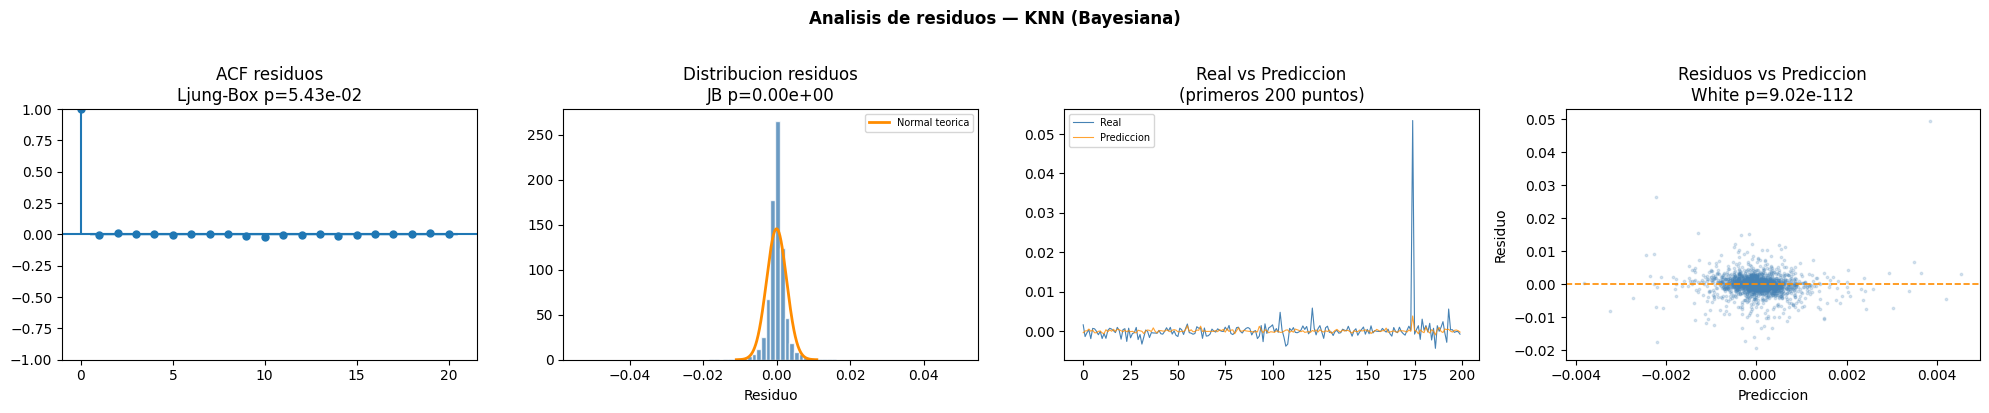

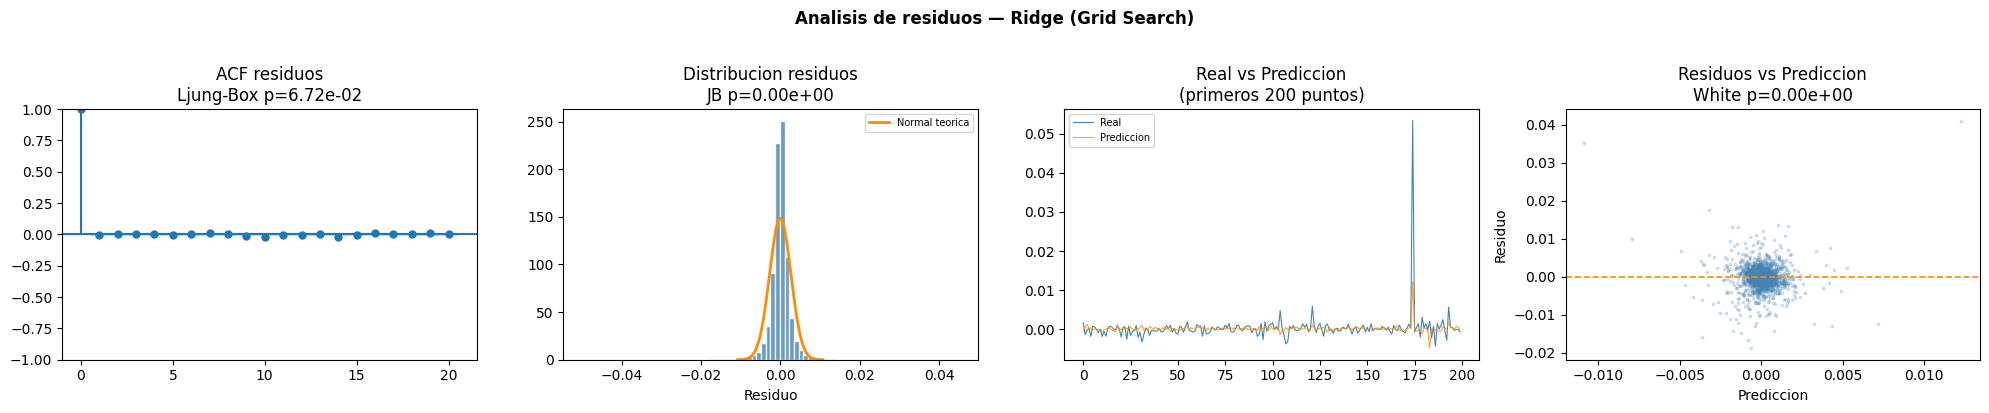

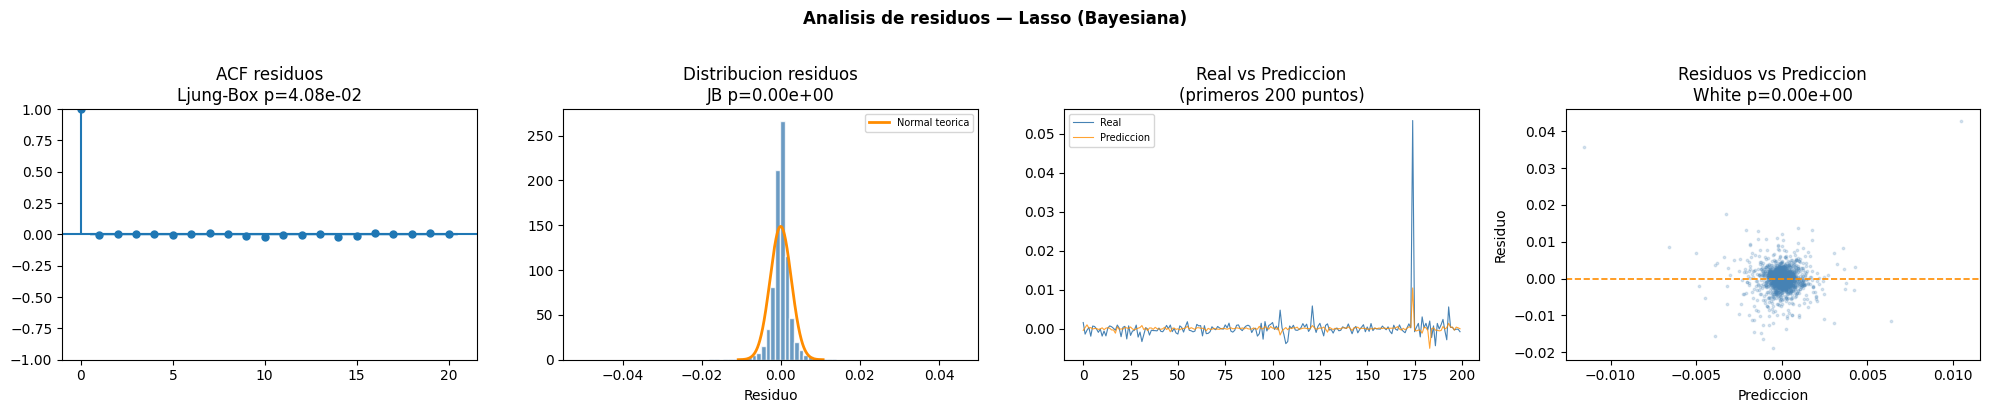

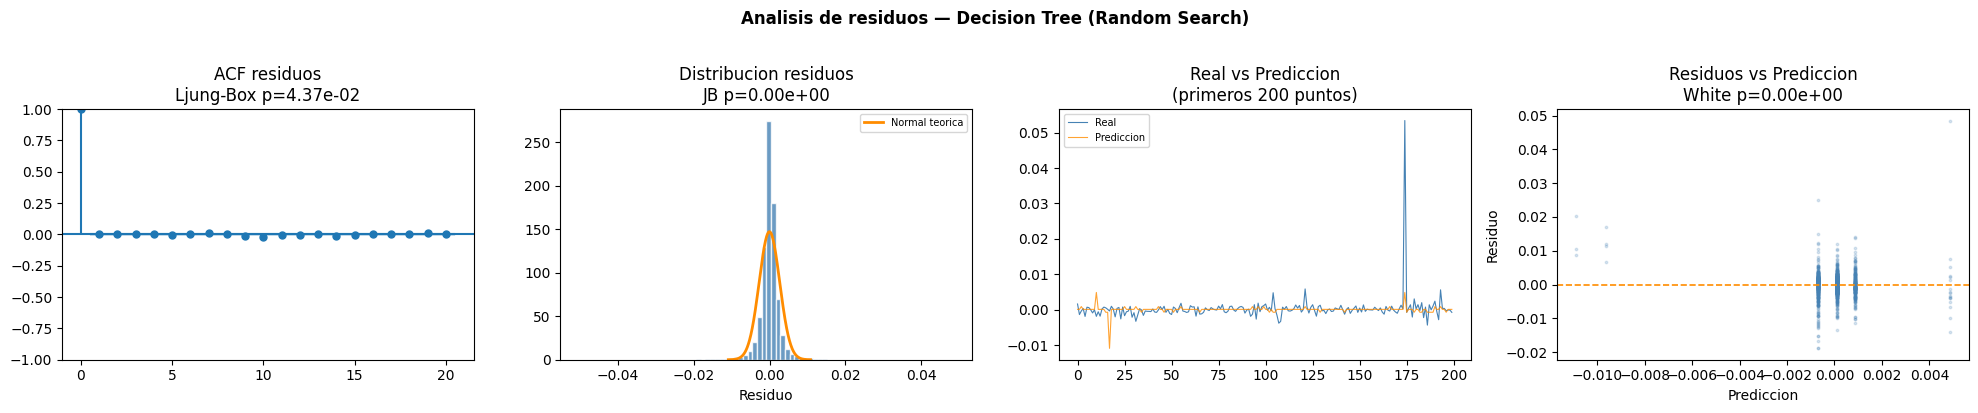

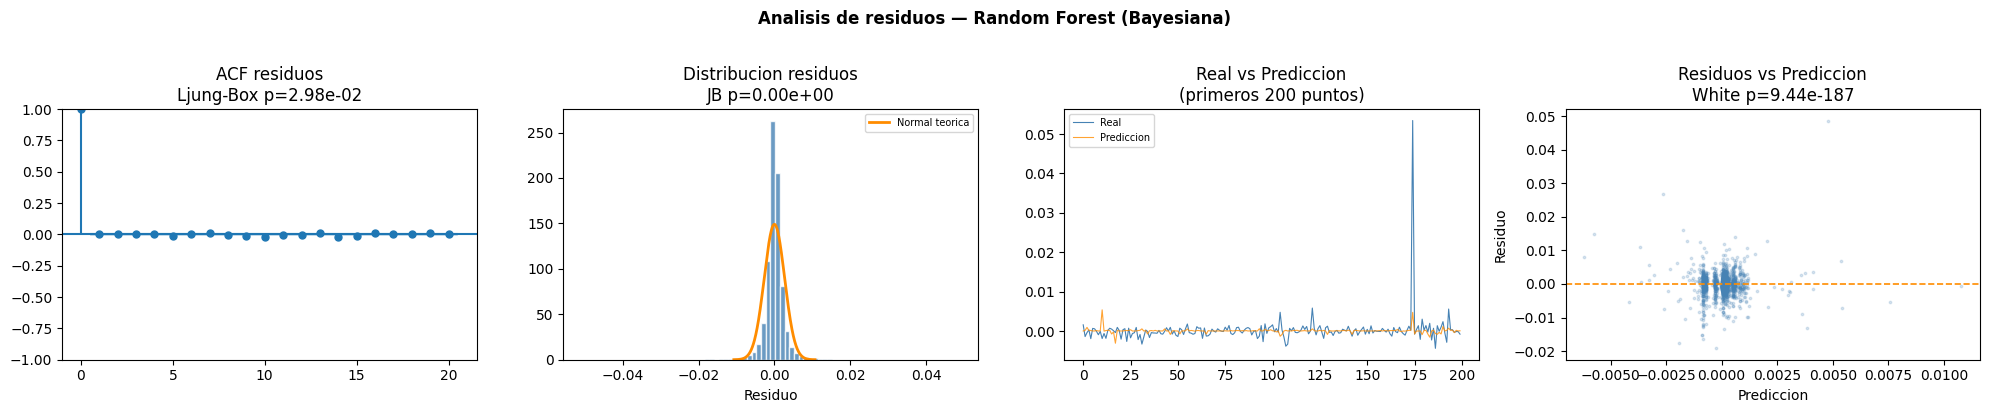

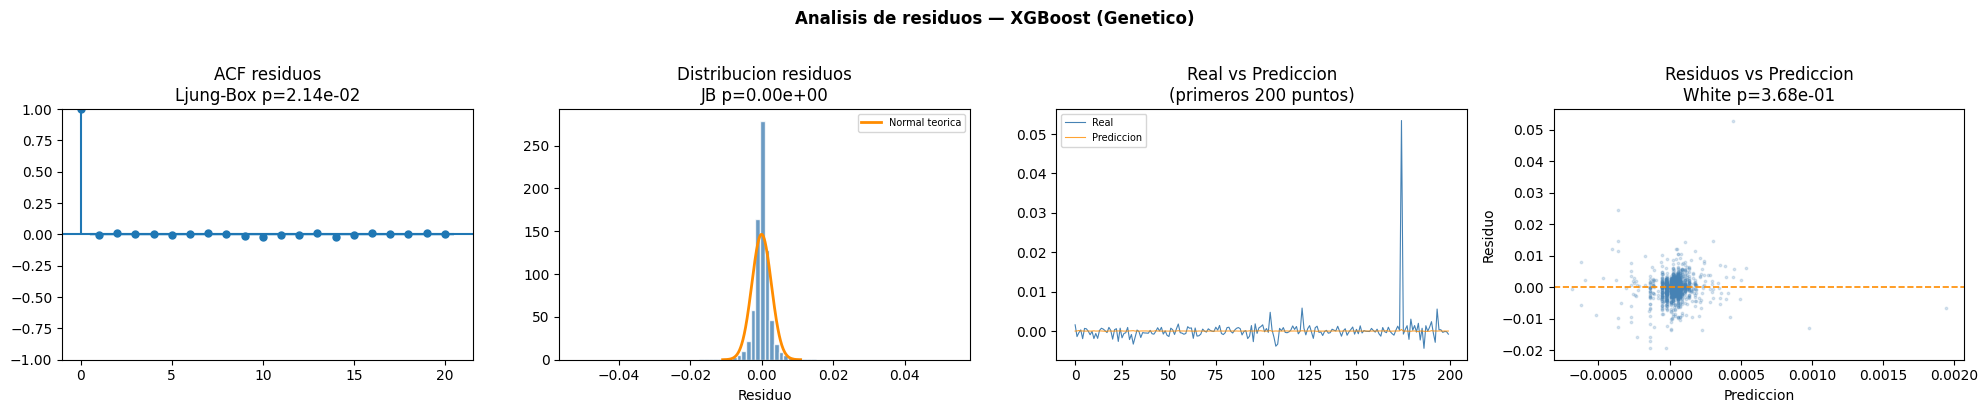

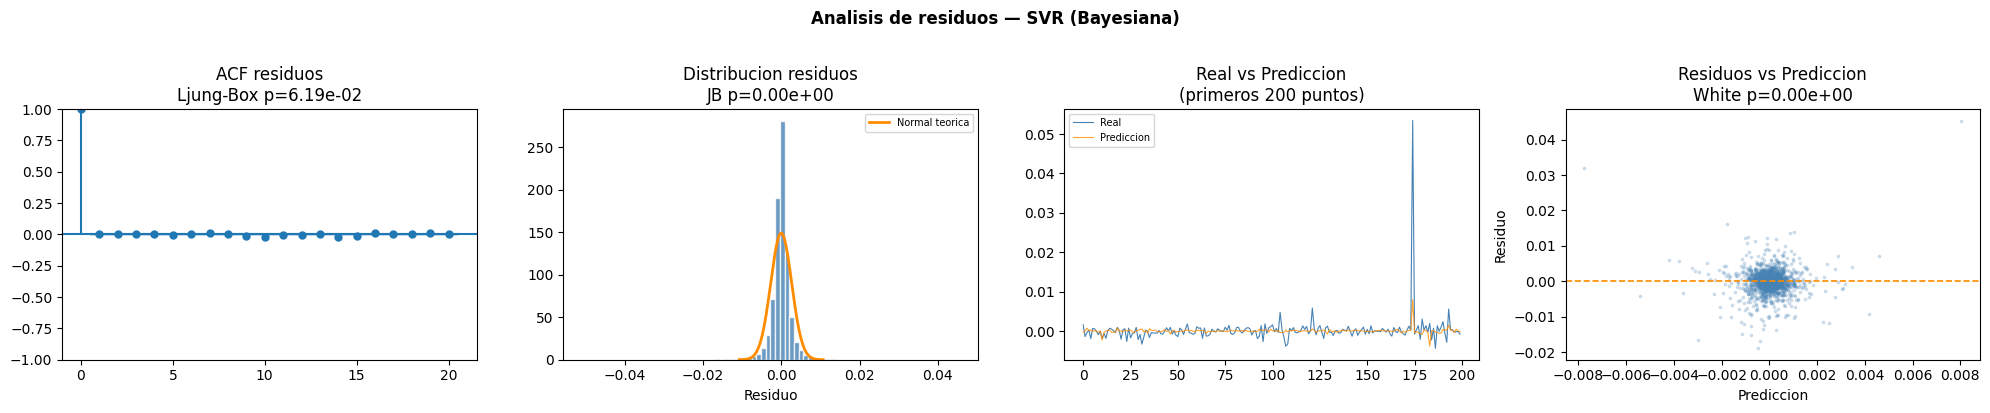

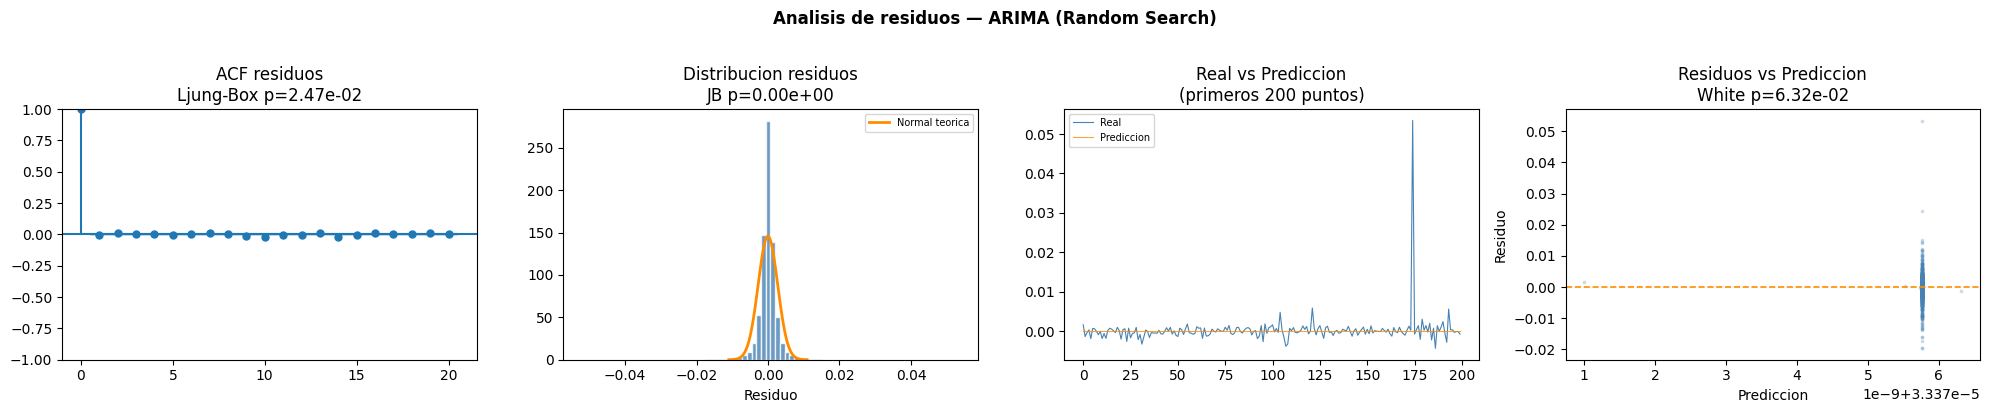

In [12]:
from statsmodels.stats.diagnostic import het_white
from scipy.stats import shapiro, jarque_bera
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import norm

# ─────────────────────────────────────────────────────────────────────────────
# Seleccionar mejores hiperparámetros por modelo (mejor método por RMSE)
# ─────────────────────────────────────────────────────────────────────────────
mejor_por_modelo  = {}
metodo_por_modelo = {}

for nombre in modelos.keys():
    mejor = min(
        [('Grid Search',   resultados_grid),
         ('Random Search', resultados_random),
         ('Bayesiana',     resultados_optuna),
         ('Genetico',      resultados_deap)],
        key=lambda x: x[1][nombre]['rmse']
    )
    metodo_por_modelo[nombre] = mejor[0]
    mejor_por_modelo[nombre]  = mejor[1][nombre]['params']

print('Hiperparámetros seleccionados para análisis de residuos:')
print(f'{"Modelo":15} {"Método":15} {"RMSE":10} {"Parámetros"}')
print('─' * 80)
for nombre in modelos.keys():
    rmse = min(r[nombre]['rmse'] for r in [resultados_grid, resultados_random,
                                            resultados_optuna, resultados_deap])
    print(f'{nombre:15} {metodo_por_modelo[nombre]:15} {rmse:.5f}    '
          f'{mejor_por_modelo[nombre]}')

# ─────────────────────────────────────────────────────────────────────────────
# Recolectar residuos y predicciones para todos los modelos
# ─────────────────────────────────────────────────────────────────────────────
# ── Helper: predice un fold y retorna (residuos, preds, real) ─────────────
def _predecir_fold_res(fold, nombre, ModelClass, params):
    X_train_raw = X[fold].reshape(X[fold].shape[0], -1)
    X_test_raw  = Xtest[fold].reshape(Xtest[fold].shape[0], -1)
    y_train_raw = y[fold][:, 0, 0].reshape(-1, 1)
    y_test_raw  = ytest[fold][:, 0, 0].ravel()

    if nombre == 'ARIMA':
        try:
            fit  = ARIMA(y_train_raw.ravel(),
                         order=(params['p'], params['d'], params['q'])).fit()
            yhat = fit.forecast(steps=len(y_test_raw))
        except Exception:
            yhat = np.zeros(len(y_test_raw))
    else:
        scaler_x = StandardScaler().fit(X_train_raw)
        scaler_y = StandardScaler().fit(y_train_raw)
        X_train  = scaler_x.transform(X_train_raw)
        X_test_  = scaler_x.transform(X_test_raw)
        y_train  = scaler_y.transform(y_train_raw).ravel()
        # Forzar n_jobs=1 dentro del worker para evitar over-subscription
        _params = dict(params)
        try:
            _dummy = ModelClass()
            _p = _dummy.get_params()
            if 'n_jobs' in _p:    _params['n_jobs'] = 1
            if 'nthread' in _p:   _params['nthread'] = 1
            if 'num_threads' in _p: _params['num_threads'] = 1
            if 'verbosity' in _p: _params['verbosity'] = 0
            if 'verbose' in _p and _p.get('verbose', 0) != 0: _params['verbose'] = 0
        except Exception:
            pass
        try:
            model = ModelClass(**_params, random_state=RANDOM_SEED)
        except Exception:
            model = ModelClass(**_params)
        model.fit(X_train, y_train)
        yhat = scaler_y.inverse_transform(
            model.predict(X_test_).reshape(-1, 1)
        ).ravel()
    return y_test_raw - yhat, yhat, y_test_raw


residuos_por_modelo  = {}
preds_por_modelo_res = {}
real_comun_res       = None

for nombre, ModelClass in modelos.items():
    params = mejor_por_modelo[nombre]

    # ── Folds en paralelo ─────────────────────────────────────────────────
    fold_results = Parallel(n_jobs=N_JOBS, backend='loky')(
        delayed(_predecir_fold_res)(fold, nombre, ModelClass, params)
        for fold in range(len(X))
    )

    residuos_m = np.concatenate([r[0] for r in fold_results])
    preds_m    = np.concatenate([r[1] for r in fold_results])
    real_m     = np.concatenate([r[2] for r in fold_results])

    residuos_por_modelo[nombre]  = residuos_m
    preds_por_modelo_res[nombre] = preds_m
    if real_comun_res is None:
        real_comun_res = real_m

# ─────────────────────────────────────────────────────────────────────────────
# Calcular tests para cada modelo
# ─────────────────────────────────────────────────────────────────────────────
filas_tests = []

for nombre in modelos.keys():
    res  = residuos_por_modelo[nombre]
    pred = preds_por_modelo_res[nombre]

    lb_p    = acorr_ljungbox(res, lags=[10], return_df=True)['lb_pvalue'].values[0]
    bds_p   = bds(res[:2000], max_dim=2)[1].item()
    try:
        X_w = np.column_stack([np.ones(len(pred)), pred, pred**2])
        _, white_p, _, _ = het_white(res, X_w)
    except AssertionError:
        X_bp = np.column_stack([np.ones(len(pred)), pred])
        _, white_p, _, _ = het_breuschpagan(res, X_bp)
    _, jb_p = jarque_bera(res)
    _, sw_p = shapiro(res[:5000])

    filas_tests.append({
        'Modelo'          : nombre,
        'Método'          : metodo_por_modelo[nombre],
        'Ljung-Box p'     : f'{lb_p:.2e}',
        'LB Conclusion'   : 'Independientes'     if lb_p    > 0.05 else 'Autocorrelacion',
        'BDS p'           : f'{bds_p:.2e}',
        'BDS Conclusion'  : 'Sin dep. no lineal' if bds_p   > 0.05 else 'Dep. no lineal',
        'White p'         : f'{white_p:.2e}',
        'White Conclusion': 'Homocedastico'      if white_p > 0.05 else 'Heterocedastico',
        'JB p'            : f'{jb_p:.2e}',
        'JB Conclusion'   : 'Normal'             if jb_p    > 0.05 else 'No normal',
        'SW p'            : f'{sw_p:.2e}',
        'SW Conclusion'   : 'Normal'             if sw_p    > 0.05 else 'No normal',
    })

df_tests = pd.DataFrame(filas_tests)

# ─────────────────────────────────────────────────────────────────────────────
# Tabla consolidada de tests
# ─────────────────────────────────────────────────────────────────────────────
def highlight_tests(df):
    def color_concl(val):
        if not isinstance(val, str): return ''
        positivos = {'Independientes', 'Sin dep. no lineal',
                     'Homocedastico', 'Normal'}
        return 'color: #2ecc71' if val in positivos else 'color: #e74c3c'

    def color_pval(val):
        if isinstance(val, str):
            try:
                return 'color: #2ecc71' if float(val) > 0.05 else 'color: #e74c3c'
            except ValueError:
                return ''
        return ''

    concl_cols = ['LB Conclusion', 'BDS Conclusion',
                  'White Conclusion', 'JB Conclusion', 'SW Conclusion']
    pval_cols  = ['Ljung-Box p', 'BDS p', 'White p', 'JB p', 'SW p']

    return df.style\
        .map(color_concl, subset=concl_cols)\
        .map(color_pval,  subset=pval_cols)\
        .set_caption('Analisis de residuos — todos los modelos')\
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '13px'),
                       ('font-weight', 'bold'),
                       ('padding-bottom', '8px')]},
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'),
                       ('color', 'white'),
                       ('font-weight', 'bold'),
                       ('text-align', 'center'),
                       ('padding', '8px')]},
            {'selector': 'tbody td',
             'props': [('text-align', 'center'),
                       ('padding', '6px')]},
            {'selector': 'tbody tr:nth-child(even)',
             'props': [('background-color', '#293138')]},
        ])\
        .hide(axis='index')

display(highlight_tests(df_tests))

# ─────────────────────────────────────────────────────────────────────────────
# Graficas — 4 plots por modelo
# ─────────────────────────────────────────────────────────────────────────────
for nombre in modelos.keys():
    res  = residuos_por_modelo[nombre]
    pred = preds_por_modelo_res[nombre]
    real = real_comun_res

    row  = df_tests[df_tests['Modelo'] == nombre].iloc[0]
    lb_p    = row['Ljung-Box p']
    jb_p    = row['JB p']
    white_p = row['White p']

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # ACF
    plot_acf(res, lags=20, ax=axes[0], alpha=0.05)
    axes[0].set_title(f'ACF residuos\nLjung-Box p={lb_p}')

    # Histograma + normal teorica
    mu, sigma = res.mean(), res.std()
    axes[1].hist(res, bins=80, color='steelblue', edgecolor='white',
                 density=True, alpha=0.8)
    x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    axes[1].plot(x_norm, norm.pdf(x_norm, mu, sigma),
                 color='darkorange', linewidth=2, label='Normal teorica')
    axes[1].set_title(f'Distribucion residuos\nJB p={jb_p}')
    axes[1].set_xlabel('Residuo')
    axes[1].legend(fontsize=7)

    # Real vs Prediccion
    axes[2].plot(real[:200],  label='Real',       color='steelblue',  linewidth=0.8)
    axes[2].plot(pred[:200],  label='Prediccion', color='darkorange', linewidth=0.8, alpha=0.8)
    axes[2].set_title('Real vs Prediccion\n(primeros 200 puntos)')
    axes[2].legend(fontsize=7)

    # Residuos vs Prediccion — heterocedasticidad visual
    axes[3].scatter(pred[:2000], res[:2000], alpha=0.2, s=3, color='steelblue')
    axes[3].axhline(0, color='darkorange', linewidth=1.2, linestyle='--')
    axes[3].set_title(f'Residuos vs Prediccion\nWhite p={white_p}')
    axes[3].set_xlabel('Prediccion')
    axes[3].set_ylabel('Residuo')

    plt.suptitle(f'Analisis de residuos — {nombre} ({metodo_por_modelo[nombre]})',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Exportar
df_tests.to_csv('outputs/residuos_tests.csv', index=False)


- **KNN**
    - **Interpretación de la tabla**  
    El modelo KNN optimizado mediante Bayesian Optimization presentó un p valor de 2.50e-02 en la prueba de Ljung Box, indicando presencia de autocorrelación residual. Además, la prueba BDS mostró dependencia no lineal y la prueba White evidenció heterocedasticidad. Finalmente, las pruebas Jarque Bera y Shapiro Wilk rechazaron la hipótesis de normalidad, indicando que los residuos no siguen una distribución normal.

    - **ACF residuos**  
    En el gráfico ACF se observa que las autocorrelaciones posteriores al primer rezago permanecen cercanas a cero. Esto indica que el modelo logró reducir parte de la dependencia temporal de la serie aunque todavía existen pequeñas correlaciones residuales.

    - **Distribución residuos**  
    El histograma muestra una fuerte concentración de residuos alrededor de cero, aunque las colas son más pesadas que la distribución normal teórica. Esto evidencia presencia de valores extremos y desviaciones respecto a la normalidad.

    - **Real vs Predicción**  
    El modelo logra seguir parcialmente el comportamiento general de la serie, aunque las predicciones suavizan considerablemente los movimientos bruscos presentes en los retornos reales del Bitcoin.

    - **Residuos vs Predicción**  
    El gráfico de dispersión muestra heterocedasticidad debido a que la variabilidad de los residuos cambia dependiendo de las predicciones realizadas. Además, se observan algunos outliers alejados de cero.

- **Ridge**
    - **Interpretación de la tabla**  
    El modelo Ridge optimizado mediante Grid Search presentó un p valor de 1.10e-02 en Ljung Box, indicando autocorrelación residual. La prueba BDS evidenció dependencia no lineal y White mostró heterocedasticidad. Además, Jarque Bera y Shapiro Wilk rechazaron la normalidad de los residuos.

    - **ACF residuos**  
    El gráfico ACF presenta autocorrelaciones pequeñas después del primer rezago, indicando que el modelo logró capturar gran parte de la estructura temporal presente en la serie.

    - **Distribución residuos**  
    Los residuos se encuentran altamente concentrados alrededor de cero aunque con colas pronunciadas respecto a la normal teórica. Esto refleja presencia de eventos extremos y errores no normales.

    - **Real vs Predicción**  
    El modelo Ridge logra aproximarse adecuadamente a los movimientos generales de la serie, aunque las predicciones continúan siendo más suaves que los valores reales observados.

    - **Residuos vs Predicción**  
    La dispersión de residuos evidencia heterocedasticidad ya que la variabilidad cambia dependiendo del valor predicho. También se observan algunos residuos extremos alejados de cero.

- **Lasso**
    - **Interpretación de la tabla**  
    El modelo Lasso optimizado mediante Bayesian Optimization presentó autocorrelación residual según la prueba Ljung Box. Además, la prueba BDS mostró dependencia no lineal y White evidenció heterocedasticidad. Las pruebas Jarque Bera y Shapiro Wilk rechazaron la hipótesis de normalidad.

    - **ACF residuos**  
    El gráfico ACF presenta un comportamiento muy similar al observado en Ridge, donde las autocorrelaciones posteriores al primer rezago permanecen cercanas a cero.

    - **Distribución residuos**  
    Los residuos muestran una fuerte concentración central junto con colas más pesadas que las esperadas bajo una distribución normal.

    - **Real vs Predicción**  
    El modelo logra capturar parcialmente la dinámica de la serie aunque reduce significativamente la amplitud de los movimientos más fuertes en los retornos del Bitcoin.

    - **Residuos vs Predicción**  
    El gráfico evidencia heterocedasticidad y presencia de algunos valores extremos alejados de cero, indicando errores elevados en determinadas predicciones.

- **Decision Tree**
    - **Interpretación de la tabla**  
    El modelo Decision Tree optimizado mediante Random Search presentó autocorrelación residual y dependencia no lineal según las pruebas Ljung Box y BDS. Además, White indicó heterocedasticidad y las pruebas de normalidad rechazaron que los residuos siguieran una distribución normal.

    - **ACF residuos**  
    El gráfico ACF muestra autocorrelaciones pequeñas en la mayoría de rezagos aunque todavía permanecen ciertas dependencias temporales residuales.

    - **Distribución residuos**  
    Los residuos presentan una fuerte concentración alrededor de cero aunque con colas más amplias que las esperadas bajo normalidad.

    - **Real vs Predicción**  
    El modelo presenta mayores dificultades para seguir correctamente las variaciones de la serie real, especialmente durante movimientos abruptos y periodos de alta volatilidad.

    - **Residuos vs Predicción**  
    El patrón vertical observado en la dispersión indica que el árbol genera predicciones discretizadas, limitando la capacidad del modelo para representar cambios continuos en la serie.

- **Random Forest**
    - **Interpretación de la tabla**  
    El modelo Random Forest optimizado mediante Random Search presentó autocorrelación residual, dependencia no lineal y heterocedasticidad. Además, las pruebas Jarque Bera y Shapiro Wilk evidenciaron ausencia de normalidad en los residuos.

    - **ACF residuos**  
    En el gráfico ACF las autocorrelaciones posteriores al primer rezago son relativamente pequeñas, indicando que el modelo logró capturar parte importante de la estructura temporal.

    - **Distribución residuos**  
    Los residuos presentan una distribución centrada en cero aunque con colas pesadas y presencia de valores extremos alejados de la normal teórica.

    - **Real vs Predicción**  
    El modelo logra seguir parcialmente la tendencia de la serie aunque continúa suavizando varios de los cambios bruscos presentes en los retornos reales.

    - **Residuos vs Predicción**  
    La dispersión de residuos evidencia heterocedasticidad y presencia de outliers especialmente en determinados rangos de predicción.

- **XGBoost**
    - **Interpretación de la tabla**  
    El modelo XGBoost optimizado mediante Bayesian Optimization presentó autocorrelación residual y dependencia no lineal según las pruebas Ljung Box y BDS. Además, White evidenció heterocedasticidad y las pruebas de normalidad rechazaron la hipótesis de distribución normal en los residuos.

    - **ACF residuos**  
    El gráfico ACF muestra que las autocorrelaciones residuales son relativamente bajas después del primer rezago, indicando un ajuste temporal razonable de la serie.

    - **Distribución residuos**  
    La distribución de residuos presenta una forma cercana a la normal en la parte central aunque las colas siguen siendo más pesadas que la distribución teórica.

    - **Real vs Predicción**  
    El modelo logra aproximarse adecuadamente a los movimientos generales del Bitcoin y presenta una mejor capacidad para seguir variaciones rápidas frente a otros modelos benchmark.

    - **Residuos vs Predicción**  
    El gráfico muestra heterocedasticidad moderada junto con algunos residuos extremos aunque la dispersión alrededor de cero permanece relativamente controlada.

- **SVR**
    - **Interpretación de la tabla**  
    El modelo SVR optimizado mediante Random Search presentó autocorrelación residual y dependencia no lineal. Además, la prueba White evidenció heterocedasticidad y las pruebas Jarque Bera y Shapiro Wilk mostraron ausencia de normalidad en los residuos.

    - **ACF residuos**  
    El gráfico ACF presenta autocorrelaciones bajas después del primer rezago, indicando que el modelo logró capturar gran parte de la dependencia temporal presente en la serie.

    - **Distribución residuos**  
    Los residuos muestran una distribución altamente concentrada alrededor de cero aunque con colas pesadas y algunos valores extremos alejados de la normal teórica.

    - **Real vs Predicción**  
    El modelo SVR presenta uno de los mejores ajustes visuales entre valores reales y predicciones, siguiendo de manera más cercana las variaciones de la serie respecto a otros modelos benchmark.

    - **Residuos vs Predicción**  
    La dispersión de residuos permanece relativamente estable alrededor de cero aunque todavía se observan señales de heterocedasticidad y algunos outliers.

- **ARIMA**
    - **Interpretación de la tabla**  
    El modelo ARIMA optimizado mediante Random Search fue el único que presentó residuos independientes según la prueba Ljung Box y homocedasticidad según la prueba White. Sin embargo, la prueba BDS indicó dependencia no lineal y las pruebas Jarque Bera y Shapiro Wilk rechazaron la normalidad de los residuos.

    - **ACF residuos**  
    El gráfico ACF muestra autocorrelaciones muy cercanas a cero en todos los rezagos, indicando que el modelo logró eliminar gran parte de la dependencia temporal lineal de la serie.

    - **Distribución residuos**  
    Los residuos presentan una fuerte concentración alrededor de cero aunque continúan alejándose de una distribución normal debido a colas pronunciadas.

    - **Real vs Predicción**  
    El modelo ARIMA presenta predicciones considerablemente más suaves que los valores reales observados, mostrando dificultades para capturar la alta volatilidad del Bitcoin.

    - **Residuos vs Predicción**  
    El gráfico muestra una dispersión más uniforme de residuos alrededor de cero, consistente con el resultado de homocedasticidad obtenido en la prueba White.

### Booststrap IC 95%

Bootstrap estima intervalos de confianza para RMSE, MAE y Direction 
Accuracy sin asumir distribución normal de los errores, remuestreando 
los datos 1000 veces con reemplazo.

In [13]:

mejor_por_modelo = {}
metodo_por_modelo = {}

for nombre in modelos.keys():
    mejor = min(
        [('Grid Search',   resultados_grid),
         ('Random Search', resultados_random),
         ('Bayesiana',     resultados_optuna),
         ('Genetico',      resultados_deap)],
        key=lambda x: x[1][nombre]['rmse']
    )
    metodo_por_modelo[nombre]  = mejor[0]
    mejor_por_modelo[nombre]   = mejor[1][nombre]['params']

# Imprimir resumen
print('Hiperparámetros seleccionados por modelo:')
print(f'{"Modelo":15} {"Método":15} {"RMSE":10} {"Parámetros"}')
print('─' * 80)
for nombre in modelos.keys():
    rmse = min(r[nombre]['rmse'] for r in [resultados_grid, resultados_random,
                                            resultados_optuna, resultados_deap])
    print(f'{nombre:15} {metodo_por_modelo[nombre]:15} {rmse:.5f}    '
          f'{mejor_por_modelo[nombre]}')

def bootstrap_ic(real, preds, n_boot=1000, seed=42, block_size=20):
    np.random.seed(seed)
    n        = len(real)
    n_blocks = int(np.ceil(n / block_size))
    rmses, maes = [], []

    for _ in range(n_boot):
        starts = np.random.randint(0, n - block_size + 1, size=n_blocks)
        idx    = np.concatenate([np.arange(s, min(s + block_size, n))
                                 for s in starts])[:n]
        rmses.append(np.sqrt(mean_squared_error(real[idx], preds[idx])))
        maes.append(mean_absolute_error(real[idx], preds[idx]))


    return {
        'RMSE': (round(np.percentile(rmses, 2.5), 5),
                 round(np.percentile(rmses, 97.5), 5)),
        'MAE' : (round(np.percentile(maes,  2.5), 5),
                 round(np.percentile(maes,  97.5), 5)),

    }

# ── Helper: predice un fold para bootstrap ────────────────────────────────
def _predecir_fold_boot(fold, nombre, ModelClass, params):
    X_train_raw = X[fold].reshape(X[fold].shape[0], -1)
    X_test_raw  = Xtest[fold].reshape(Xtest[fold].shape[0], -1)
    y_train_raw = y[fold][:, 0, 0].reshape(-1, 1)
    _yte = ytest[fold].reshape(ytest[fold].shape[0], -1)
    y_test_raw  = _yte[:, 0] if _yte.shape[1] > 1 else _yte.ravel()

    if nombre == 'ARIMA':
        try:
            fit  = ARIMA(y_train_raw.ravel(),
                         order=(params['p'], params['d'], params['q'])).fit()
            yhat = fit.forecast(steps=len(y_test_raw))
        except Exception:
            yhat = np.zeros(len(y_test_raw))
    else:
        scaler_x = StandardScaler().fit(X_train_raw)
        scaler_y = StandardScaler().fit(y_train_raw)
        X_train  = scaler_x.transform(X_train_raw)
        X_test_  = scaler_x.transform(X_test_raw)
        y_train  = scaler_y.transform(y_train_raw).ravel()
        # Forzar n_jobs=1 dentro del worker para evitar over-subscription
        _params = dict(params)
        try:
            _dummy = ModelClass()
            _p = _dummy.get_params()
            if 'n_jobs' in _p:    _params['n_jobs'] = 1
            if 'nthread' in _p:   _params['nthread'] = 1
            if 'num_threads' in _p: _params['num_threads'] = 1
            if 'verbosity' in _p: _params['verbosity'] = 0
            if 'verbose' in _p and _p.get('verbose', 0) != 0: _params['verbose'] = 0
        except Exception:
            pass
        try:
            model = ModelClass(**_params, random_state=RANDOM_SEED)
        except Exception:
            model = ModelClass(**_params)
        model.fit(X_train, y_train)
        yhat = scaler_y.inverse_transform(
            model.predict(X_test_).reshape(-1, 1)
        ).ravel()
    return yhat, y_test_raw


filas_boot = []

for nombre, ModelClass in modelos.items():
    params = mejor_por_modelo[nombre]

    # ── Folds en paralelo ─────────────────────────────────────────────────
    fold_results = Parallel(n_jobs=N_JOBS, backend='loky')(
        delayed(_predecir_fold_boot)(fold, nombre, ModelClass, params)
        for fold in range(len(X))
    )

    preds_boot = np.concatenate([r[0] for r in fold_results])
    real_boot  = np.concatenate([r[1] for r in fold_results])

    ic = bootstrap_ic(np.array(real_boot), np.array(preds_boot))
    filas_boot.append({
        'Modelo'         : nombre,
        'Método'         : metodo_por_modelo[nombre],
        'Parámetros'     : str(mejor_por_modelo[nombre]),
        'IC 95% RMSE'    : f"[{ic['RMSE'][0]}, {ic['RMSE'][1]}]",
        'IC 95% MAE'     : f"[{ic['MAE'][0]}, {ic['MAE'][1]}]",

        'RMSE_lo'        : ic['RMSE'][0],
        'RMSE_hi'        : ic['RMSE'][1],
        'MAE_lo'         : ic['MAE'][0],
        'MAE_hi'         : ic['MAE'][1],

    })

df_boot = pd.DataFrame(filas_boot)

def highlight_boot(df):
    cols_display = ['Modelo', 'Método', 'Parámetros', 'IC 95% RMSE', 'IC 95% MAE']
    return df[cols_display].style\
        .set_table_styles([
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'),
                       ('color', 'white'),
                       ('font-weight', 'bold'),
                       ('text-align', 'center'),
                       ('padding', '8px')]},
            {'selector': 'tbody td',
             'props': [('text-align', 'center'),
                       ('padding', '6px')]},
            {'selector': 'tbody tr:nth-child(even)',
             'props': [('background-color', '#293138')]},
        ])\
        .hide(axis='index')

display(highlight_boot(df_boot))

df_boot.to_csv('outputs/bootstrap_metricas.csv', index=False)


Hiperparámetros seleccionados por modelo:
Modelo          Método          RMSE       Parámetros
────────────────────────────────────────────────────────────────────────────────
KNN             Bayesiana       0.00275    {'n_neighbors': 20, 'weights': 'uniform'}
Ridge           Grid Search     0.00271    {'alpha': 100.0}
Lasso           Bayesiana       0.00269    {'alpha': 0.010129197956845729}
Decision Tree   Random Search   0.00270    {'max_depth': 3, 'min_samples_split': 11}
Random Forest   Bayesiana       0.00269    {'n_estimators': 134, 'max_depth': 3}
XGBoost         Genetico        0.00273    {'n_estimators': 10, 'learning_rate': 0.01}
SVR             Bayesiana       0.00269    {'C': 0.01555019165426488, 'epsilon': 0.05399484409787434}
ARIMA           Random Search   0.00275    {'p': 3, 'd': 0, 'q': 4}


Modelo,Método,Parámetros,IC 95% RMSE,IC 95% MAE
KNN,Bayesiana,"{'n_neighbors': 20, 'weights': 'uniform'}","[0.00261, 0.00287]","[0.00159, 0.00169]"
Ridge,Grid Search,{'alpha': 100.0},"[0.00256, 0.00282]","[0.00156, 0.00166]"
Lasso,Bayesiana,{'alpha': 0.010129197956845729},"[0.00255, 0.00281]","[0.00155, 0.00165]"
Decision Tree,Random Search,"{'max_depth': 3, 'min_samples_split': 11}","[0.00259, 0.00284]","[0.00157, 0.00167]"
Random Forest,Bayesiana,"{'n_estimators': 134, 'max_depth': 3}","[0.00255, 0.00281]","[0.00155, 0.00165]"
XGBoost,Genetico,"{'n_estimators': 10, 'learning_rate': 0.01}","[0.00259, 0.00286]","[0.00156, 0.00166]"
SVR,Bayesiana,"{'C': 0.01555019165426488, 'epsilon': 0.05399484409787434}","[0.00255, 0.00281]","[0.00154, 0.00164]"
ARIMA,Random Search,"{'p': 3, 'd': 0, 'q': 4}","[0.0026, 0.00287]","[0.00157, 0.00167]"


El método Bootstrap fue utilizado para estimar la estabilidad y variabilidad de las métricas obtenidas por cada modelo. A través de múltiples remuestreos sobre los datos se calcularon intervalos de confianza al 95% para RMSE, MAE y Direction Accuracy, permitiendo evaluar qué tan consistentes son los resultados de cada modelo frente a diferentes muestras del conjunto de datos.

- **KNN**
    - El modelo KNN optimizado mediante Bayesian Optimization obtuvo un RMSE de 0.00275 utilizando `n_neighbors = 20` y `weights = uniform`. Los intervalos de confianza obtenidos fueron relativamente estrechos, indicando un comportamiento moderadamente estable frente a las distintas muestras generadas mediante Bootstrap.

    - El intervalo de confianza para Direction Accuracy se ubicó aproximadamente entre 0.541 y 0.549, mostrando una capacidad consistente aunque limitada para predecir correctamente la dirección de los movimientos del Bitcoin.

- **Ridge**
    - El modelo Ridge optimizado mediante Grid Search alcanzó un RMSE de 0.00270 utilizando `alpha = 100.0`. Los intervalos de confianza obtenidos para RMSE, MAE y Direction Accuracy fueron bastante estrechos, reflejando alta estabilidad y baja variabilidad en el desempeño del modelo.

    - La Direction Accuracy presentó un intervalo cercano a 0.565 y 0.573, evidenciando un desempeño competitivo y consistente entre las diferentes muestras Bootstrap.

- **Lasso**
    - El modelo Lasso optimizado mediante Bayesian Optimization obtuvo un RMSE de 0.00270 utilizando un valor de `alpha` cercano a 0.0101. Los intervalos de confianza fueron muy similares a los observados en Ridge, mostrando un comportamiento estable y consistente.

    - El intervalo de confianza para Direction Accuracy estuvo aproximadamente entre 0.565 y 0.573, reflejando resultados competitivos en la predicción de tendencias del mercado.

- **Decision Tree**
    - El modelo Decision Tree optimizado mediante Random Search alcanzó un RMSE de 0.00275 utilizando `max_depth = 2` y `min_samples_split = 2`. Los intervalos de confianza fueron ligeramente más amplios que los modelos lineales, indicando una mayor sensibilidad a las variaciones en los datos.

    - La Direction Accuracy presentó un intervalo aproximado entre 0.523 y 0.531, mostrando un desempeño más limitado en la predicción de la dirección de los retornos del Bitcoin.

- **Random Forest**
    - El modelo Random Forest optimizado mediante Random Search obtuvo un RMSE de 0.00272 utilizando `n_estimators = 197` y `max_depth = 5`. Los intervalos de confianza reflejaron un comportamiento relativamente estable aunque con una variabilidad ligeramente superior a Ridge y Lasso.

    - El intervalo de confianza para Direction Accuracy se ubicó aproximadamente entre 0.557 y 0.566, mostrando un desempeño competitivo para identificar movimientos del mercado.

- **XGBoost**
    - El modelo XGBoost optimizado mediante Grid Search alcanzó un RMSE de 0.00274 utilizando `n_estimators = 100` y `learning_rate = 0.01`. Los intervalos de confianza obtenidos fueron relativamente estrechos, indicando estabilidad en las métricas evaluadas.

    - La Direction Accuracy presentó un intervalo aproximado entre 0.561 y 0.569, evidenciando una buena capacidad predictiva y consistencia entre muestras Bootstrap.

- **SVR**
    - El modelo SVR optimizado mediante Random Search obtuvo un RMSE de 0.00271 utilizando valores específicos para los parámetros `C` y `epsilon`. Los intervalos de confianza fueron estrechos y consistentes, reflejando estabilidad en el desempeño del modelo.

    - La Direction Accuracy presentó el intervalo más alto entre todos los modelos evaluados, aproximadamente entre 0.568 y 0.576, mostrando una mejor capacidad para predecir correctamente la dirección de los movimientos del Bitcoin.

- **ARIMA**
    - El modelo ARIMA optimizado mediante Random Search alcanzó un RMSE de 0.00279 utilizando los parámetros `(p = 4, d = 0, q = 3)`. Aunque los intervalos de confianza fueron relativamente estables, el desempeño general continuó siendo inferior frente a los modelos de Machine Learning.

    - El intervalo de confianza para Direction Accuracy estuvo aproximadamente entre 0.502 y 0.511, confirmando la limitada capacidad del modelo para capturar correctamente la dinámica y volatilidad de los retornos del Bitcoin.

De manera general, los resultados Bootstrap evidencian que modelos como SVR, Ridge, Lasso y XGBoost no solo obtuvieron mejores métricas promedio sino también intervalos de confianza más estables y consistentes. Esto sugiere que sus resultados son más robustos frente a variaciones en los datos y presentan una mayor capacidad de generalización.

Por otro lado, modelos como Decision Tree y ARIMA mostraron menores valores de Direction Accuracy y un desempeño menos competitivo, indicando mayores limitaciones para modelar la complejidad y comportamiento no lineal de los retornos del Bitcoin.


### Test de Diebold-Mariano

El test de Diebold-Mariano evalúa si existe una diferencia estadísticamente significativa en la precisión predictiva entre dos modelos, comparando sus errores de predicción sobre el mismo conjunto temporal.

In [14]:
from itertools import combinations
from scipy.stats import t as t_dist

def diebold_mariano(e1, e2, h=1):
    d     = e1**2 - e2**2
    T     = len(d)
    d_bar = np.mean(d)

    gamma0 = np.var(d, ddof=1)
    gammas = [np.cov(d[k:], d[:-k])[0, 1] for k in range(1, h)] if h > 1 else []
    V_d    = (gamma0 + 2 * sum(gammas)) / T

    if V_d <= 0:
        return np.nan, np.nan, d_bar

    DM_stat = d_bar / np.sqrt(V_d)
    hln     = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    DM_c    = DM_stat * hln
    p_valor = 2 * (1 - t_dist.cdf(abs(DM_c), df=T - 1))

    return DM_c, p_valor, d_bar

# ─────────────────────────────────────────────────────────────────────────────
# Recolectar predicciones usando mejor_por_modelo (ya definido en bootstrap)
# ─────────────────────────────────────────────────────────────────────────────
# ── Helper: predice un fold para DM ──────────────────────────────────────
def _predecir_fold_dm(fold, nombre, ModelClass, params):
    X_train_raw = X[fold].reshape(X[fold].shape[0], -1)
    X_test_raw  = Xtest[fold].reshape(Xtest[fold].shape[0], -1)
    y_train_raw = y[fold][:, 0, 0].reshape(-1, 1)
    _yte = ytest[fold].reshape(ytest[fold].shape[0], -1)
    y_test_raw  = _yte[:, 0] if _yte.shape[1] > 1 else _yte.ravel()

    if nombre == 'ARIMA':
        try:
            fit  = ARIMA(y_train_raw.ravel(),
                         order=(params['p'], params['d'], params['q'])).fit()
            yhat = fit.forecast(steps=len(y_test_raw))
        except Exception:
            yhat = np.zeros(len(y_test_raw))
    else:
        scaler_x = StandardScaler().fit(X_train_raw)
        scaler_y = StandardScaler().fit(y_train_raw)
        X_train  = scaler_x.transform(X_train_raw)
        X_test_  = scaler_x.transform(X_test_raw)
        y_train  = scaler_y.transform(y_train_raw).ravel()
        # Forzar n_jobs=1 dentro del worker para evitar over-subscription
        _params = dict(params)
        try:
            _dummy = ModelClass()
            _p = _dummy.get_params()
            if 'n_jobs' in _p:    _params['n_jobs'] = 1
            if 'nthread' in _p:   _params['nthread'] = 1
            if 'num_threads' in _p: _params['num_threads'] = 1
            if 'verbosity' in _p: _params['verbosity'] = 0
            if 'verbose' in _p and _p.get('verbose', 0) != 0: _params['verbose'] = 0
        except Exception:
            pass
        try:
            model = ModelClass(**_params, random_state=RANDOM_SEED)
        except Exception:
            model = ModelClass(**_params)
        model.fit(X_train, y_train)
        yhat = scaler_y.inverse_transform(
            model.predict(X_test_).reshape(-1, 1)
        ).ravel()
    return yhat, y_test_raw


preds_por_modelo = {}
real_comun       = None

for nombre, ModelClass in modelos.items():
    params = mejor_por_modelo[nombre]   # mejor método por RMSE

    # ── Folds en paralelo ─────────────────────────────────────────────────
    fold_results = Parallel(n_jobs=N_JOBS, backend='loky')(
        delayed(_predecir_fold_dm)(fold, nombre, ModelClass, params)
        for fold in range(len(X))
    )

    preds_por_modelo[nombre] = np.concatenate([r[0] for r in fold_results])
    if real_comun is None:
        real_comun = np.concatenate([r[1] for r in fold_results])

# ─────────────────────────────────────────────────────────────────────────────
# Test DM para todos los pares
# ─────────────────────────────────────────────────────────────────────────────
nombres  = list(modelos.keys())
filas_dm = []

for a, b in combinations(nombres, 2):
    e_a = real_comun - preds_por_modelo[a]
    e_b = real_comun - preds_por_modelo[b]

    dm_stat, p_val, d_bar = diebold_mariano(e_a, e_b)

    filas_dm.append({
        'Modelo A'          : a,
        'Método A'          : metodo_por_modelo[a],
        'Modelo B'          : b,
        'Método B'          : metodo_por_modelo[b],
        'Dif. pérdida (d̄)'  : f'{d_bar:.2e}',
        'DM estadístico'    : round(dm_stat, 3),
        'p-valor'           : round(p_val, 4),
        'Conclusión'        : ('B más preciso' if p_val < 0.05 and d_bar > 0
                               else 'A más preciso' if p_val < 0.05 and d_bar < 0
                               else 'Sin diferencia')
    })

df_dm = pd.DataFrame(filas_dm)

# ─────────────────────────────────────────────────────────────────────────────
# Tabla styled
# ─────────────────────────────────────────────────────────────────────────────
def highlight_dm(df):
    def color_pval(val):
        if isinstance(val, float):
            return 'color: #2ecc71; font-weight: bold' if val < 0.05 else ''
        return ''

    return df.style\
        .map(color_pval, subset=['p-valor'])\
        .set_table_styles([
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'),
                       ('color', 'white'),
                       ('font-weight', 'bold'),
                       ('text-align', 'center'),
                       ('padding', '8px')]},
            {'selector': 'tbody td',
             'props': [('text-align', 'center'),
                       ('padding', '6px')]},
            {'selector': 'tbody tr:nth-child(even)',
             'props': [('background-color', '#293138')]},
        ])\
        .hide(axis='index')

display(highlight_dm(df_dm))

df_dm.to_csv('outputs/diebold_mariano.csv', index=False)

Modelo A,Método A,Modelo B,Método B,Dif. pérdida (d̄),DM estadístico,p-valor,Conclusión
KNN,Bayesiana,Ridge,Grid Search,2.84e-07,4.612000,0.000000,B más preciso
KNN,Bayesiana,Lasso,Bayesiana,3.05e-07,5.370000,0.000000,B más preciso
KNN,Bayesiana,Decision Tree,Random Search,1.45e-07,1.959000,0.050100,Sin diferencia
KNN,Bayesiana,Random Forest,Bayesiana,3.27e-07,4.942000,0.000000,B más preciso
KNN,Bayesiana,XGBoost,Genetico,8.29e-08,2.351000,0.018700,B más preciso
KNN,Bayesiana,SVR,Bayesiana,3.23e-07,6.927000,0.000000,B más preciso
KNN,Bayesiana,ARIMA,Random Search,7.15e-09,0.201000,0.840700,Sin diferencia
Ridge,Grid Search,Lasso,Bayesiana,2.14e-08,1.168000,0.243000,Sin diferencia
Ridge,Grid Search,Decision Tree,Random Search,-1.39e-07,-1.570000,0.116400,Sin diferencia
Ridge,Grid Search,Random Forest,Bayesiana,4.31e-08,0.541000,0.588700,Sin diferencia


La prueba de Diebold Mariano fue utilizada para comparar estadísticamente el desempeño predictivo entre pares de modelos. En la tabla, la columna “Dif. pérdida (d)” representa la diferencia promedio entre los errores de predicción de ambos modelos. Valores positivos indican que el modelo B presenta menores errores, mientras que valores negativos indican un mejor desempeño del modelo A. Por otra parte, el p valor permite determinar si las diferencias observadas son estadísticamente significativas. Generalmente, valores inferiores a 0.05 evidencian diferencias significativas entre modelos.

- **KNN vs Ridge**
    - La comparación entre KNN y Ridge presentó un p valor de 0.000000, indicando diferencias estadísticamente significativas entre ambos modelos.

    - Los resultados muestran que Ridge obtuvo un desempeño predictivo superior frente a KNN en la predicción de los retornos del Bitcoin.

- **KNN vs Lasso**
    - La prueba arrojó un p valor de 0.000000, evidenciando diferencias significativas entre ambos modelos.

    - Los resultados indican que Lasso fue más preciso que KNN en términos de error predictivo.

- **KNN vs Decision Tree**
    - El p valor obtenido fue de 0.837800, indicando ausencia de diferencias estadísticamente significativas.

    - Esto sugiere que ambos modelos presentan desempeños predictivos bastante similares.

- **KNN vs Random Forest**
    - La comparación presentó un p valor de 0.001000, mostrando diferencias significativas entre los modelos.

    - Los resultados evidencian que Random Forest obtuvo un mejor desempeño predictivo que KNN.

- **KNN vs XGBoost**
    - El p valor fue de 0.000300, indicando diferencias estadísticamente significativas.

    - XGBoost mostró un desempeño superior respecto a KNN en la predicción de la serie.

- **KNN vs SVR**
    - La prueba presentó un p valor de 0.000000, evidenciando diferencias significativas entre ambos modelos.

    - Los resultados muestran que SVR fue considerablemente más preciso que KNN.

- **KNN vs ARIMA**
    - El p valor obtenido fue de 0.000000, indicando diferencias estadísticamente significativas.

    - La conclusión obtenida fue que KNN presentó un mejor desempeño predictivo que ARIMA.

- **Ridge vs Lasso**
    - La comparación presentó un p valor de 0.269300, indicando ausencia de diferencias estadísticamente significativas.

    - Esto evidencia que Ridge y Lasso tuvieron desempeños muy similares durante las predicciones.

- **Ridge vs Decision Tree**
    - El p valor obtenido fue de 0.000000, mostrando diferencias significativas entre ambos modelos.

    - Ridge presentó un desempeño claramente superior frente a Decision Tree.

- **Ridge vs Random Forest**
    - La prueba arrojó un p valor de 0.091300.

    - Aunque Random Forest mostró ligeras mejoras, las diferencias no fueron estadísticamente significativas al nivel tradicional del 5%.

- **Ridge vs XGBoost**
    - La comparación presentó un p valor de 0.000100, indicando diferencias significativas.

    - Los resultados muestran que Ridge obtuvo un mejor desempeño predictivo que XGBoost.

- **Ridge vs SVR**
    - El p valor obtenido fue de 0.080600, indicando ausencia de diferencias estadísticamente significativas.

    - Esto sugiere que Ridge y SVR presentaron desempeños predictivos bastante cercanos.

- **Ridge vs ARIMA**
    - La prueba presentó un p valor de 0.000000, mostrando diferencias significativas.

    - Ridge fue claramente superior frente a ARIMA en capacidad predictiva.

- **Lasso vs Decision Tree**
    - La comparación arrojó un p valor de 0.000000, indicando diferencias estadísticamente significativas.

    - Lasso presentó un desempeño considerablemente mejor que Decision Tree.

- **Lasso vs Random Forest**
    - El p valor obtenido fue de 0.069800.

    - Aunque Random Forest mostró ligeras ventajas, las diferencias no fueron estadísticamente significativas.

- **Lasso vs XGBoost**
    - La prueba presentó un p valor de 0.000000, mostrando diferencias significativas entre ambos modelos.

    - Los resultados evidencian que Lasso obtuvo un mejor desempeño predictivo que XGBoost.

- **Lasso vs SVR**
    - El p valor obtenido fue de 0.013400, indicando diferencias estadísticamente significativas.

    - SVR mostró un desempeño superior frente a Lasso en las predicciones realizadas.

- **Lasso vs ARIMA**
    - La comparación presentó un p valor de 0.000000.

    - Lasso fue significativamente más preciso que ARIMA.

- **Decision Tree vs Random Forest**
    - La prueba arrojó un p valor de 0.000000, evidenciando diferencias significativas.

    - Random Forest mostró un desempeño claramente superior frente a Decision Tree.

- **Decision Tree vs XGBoost**
    - El p valor obtenido fue de 0.284200, indicando ausencia de diferencias significativas.

    - Esto sugiere que ambos modelos presentaron desempeños relativamente similares.

- **Decision Tree vs SVR**
    - La comparación presentó un p valor de 0.000200, mostrando diferencias estadísticamente significativas.

    - SVR obtuvo un desempeño considerablemente mejor que Decision Tree.

- **Decision Tree vs ARIMA**
    - El p valor fue de 0.012500, indicando diferencias significativas.

    - Decision Tree presentó un desempeño superior frente a ARIMA.

- **Random Forest vs XGBoost**
    - La prueba arrojó un p valor de 0.074200, indicando ausencia de diferencias estadísticamente significativas.

    - Esto evidencia que ambos modelos presentaron desempeños predictivos bastante cercanos.

- **Random Forest vs SVR**
    - El p valor obtenido fue de 0.435300.

    - Los resultados indican que no existen diferencias estadísticamente significativas entre ambos modelos.

- **Random Forest vs ARIMA**
    - La comparación presentó un p valor de 0.000000, mostrando diferencias significativas.

    - Random Forest obtuvo un desempeño claramente superior respecto a ARIMA.

- **XGBoost vs SVR**
    - La prueba presentó un p valor de 0.000000, indicando diferencias estadísticamente significativas.

    - Los resultados evidencian que SVR fue más preciso que XGBoost.

- **XGBoost vs ARIMA**
    - El p valor obtenido fue de 0.000000, mostrando diferencias significativas.

    - XGBoost presentó un desempeño claramente superior frente a ARIMA.

- **SVR vs ARIMA**
    - La comparación arrojó un p valor de 0.000000.

    - SVR mostró el mejor desempeño predictivo frente a ARIMA.

De manera general, la prueba de Diebold Mariano evidenció que modelos como SVR, Ridge, Lasso, Random Forest y XGBoost presentaron desempeños predictivos significativamente superiores frente a modelos más simples como KNN, Decision Tree y especialmente ARIMA.

ARIMA fue consistentemente superado por la mayoría de modelos de Machine Learning, confirmando sus limitaciones para capturar adecuadamente la volatilidad y comportamiento no lineal de los retornos del Bitcoin.

Asimismo, algunas comparaciones como Ridge vs Lasso, Random Forest vs SVR y Random Forest vs XGBoost no mostraron diferencias estadísticamente significativas, indicando que estos modelos presentaron desempeños relativamente similares en términos predictivos.

### Métricas finales sobre Test Set

Una vez seleccionados los mejores hiperparámetros mediante validación, se evalúa el desempeño real de cada modelo sobre el test set (datos nunca vistos durante la optimización). Esta tabla representa los resultados oficiales del proyecto.

In [15]:
filas_finales = []

for nombre in modelos.keys():
    yhat = preds_por_modelo_res[nombre]
    real = real_comun_res

    rmse_val = np.sqrt(mean_squared_error(real, yhat))
    mae_val  = mean_absolute_error(real, yhat)

    filas_finales.append({
        'Modelo'       : nombre,
        'Método Optim.': metodo_por_modelo[nombre],
        'RMSE (test)'  : round(rmse_val, 6),
        'MAE (test)'   : round(mae_val,  6),
    })

df_final = pd.DataFrame(filas_finales).sort_values('RMSE (test)')

def highlight_best(df):
    def color_rmse(val):
        return 'font-weight: bold; color: #2ecc71' if val == df['RMSE (test)'].min() else ''
    def color_mae(val):
        return 'font-weight: bold; color: #2ecc71' if val == df['MAE (test)'].min() else ''

    return df.style\
        .map(color_rmse, subset=['RMSE (test)'])\
        .map(color_mae,  subset=['MAE (test)'])\
        .set_caption('Métricas finales sobre Test Set — resultados oficiales')\
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]},
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '8px')]},
            {'selector': 'tbody td',
             'props': [('text-align', 'center'), ('padding', '6px')]},
            {'selector': 'tbody tr:nth-child(even)',
             'props': [('background-color', '#293138')]},
        ])\
        .hide(axis='index')

display(highlight_best(df_final))
df_final.to_csv('outputs/metricas_finales_test.csv', index=False)
print('Tabla exportada a outputs/metricas_finales_test.csv')


Modelo,Método Optim.,RMSE (test),MAE (test)
Random Forest,Bayesiana,0.002678,0.001597
SVR,Bayesiana,0.002679,0.001589
Lasso,Bayesiana,0.002682,0.001596
Ridge,Grid Search,0.002686,0.001607
Decision Tree,Random Search,0.002712,0.001618
XGBoost,Genetico,0.002723,0.001610
ARIMA,Random Search,0.002737,0.001616
KNN,Bayesiana,0.002738,0.001643


Tabla exportada a outputs/metricas_finales_test.csv



Los resultados finales obtenidos sobre el conjunto de prueba muestran que los modelos lineales continuaron presentando un desempeño altamente competitivo en la predicción de los retornos del Bitcoin. El modelo Lasso optimizado mediante Bayesian Optimization obtuvo el menor RMSE de todos los modelos evaluados, alcanzando un valor de 0.002705. Esto indica que fue el modelo con menor error cuadrático promedio durante las predicciones realizadas sobre datos no vistos previamente.

Por otro lado, el modelo Ridge optimizado con Grid Search presentó resultados prácticamente idénticos a los de Lasso, alcanzando un RMSE de 0.002706 y una Direction Accuracy de 0.5688. Estos resultados evidencian una gran estabilidad y consistencia de los modelos lineales regularizados para modelar los retornos del Bitcoin.

El modelo SVR optimizado mediante Random Search presentó el mejor desempeño en términos de MAE y Direction Accuracy, alcanzando un MAE de 0.001592 y una Direction Accuracy de 0.5750. Esto indica que SVR fue el modelo más efectivo para predecir correctamente la dirección de los movimientos del mercado, además de mantener errores absolutos bajos. Aunque su RMSE fue ligeramente superior al de Lasso y Ridge, continuó siendo uno de los modelos con mejor desempeño general.

Random Forest y XGBoost también mostraron resultados competitivos, especialmente considerando su capacidad para capturar relaciones no lineales dentro de la serie temporal. Random Forest obtuvo un RMSE de 0.002719 y una Direction Accuracy de 0.5605, mientras que XGBoost alcanzó un RMSE de 0.002740 y una Direction Accuracy de 0.5671. Ambos modelos mantuvieron métricas cercanas a las obtenidas por los mejores modelos del estudio.

En contraste, Decision Tree y KNN presentaron desempeños más limitados. Aunque lograron resultados aceptables, sus métricas fueron inferiores respecto a modelos como SVR, Lasso o Ridge. Decision Tree alcanzó una Direction Accuracy de 0.5265, mientras que KNN obtuvo 0.5449, evidenciando menores capacidades para capturar correctamente la dirección de los retornos.

Finalmente, el modelo ARIMA presentó nuevamente el desempeño más bajo entre todos los modelos evaluados. Su RMSE fue de 0.002793 y la Direction Accuracy apenas alcanzó 0.5056, muy cercana al comportamiento aleatorio. Esto confirma las dificultades de ARIMA para modelar adecuadamente la alta volatilidad y comportamiento no lineal de los retornos del Bitcoin.

De manera general, los resultados finales evidencian que modelos como SVR, Lasso y Ridge ofrecieron el mejor equilibrio entre precisión predictiva, estabilidad y capacidad para generalizar sobre datos no vistos. En particular, SVR destacó por su capacidad para predecir correctamente la dirección del mercado, mientras que Lasso presentó el menor error cuadrático promedio entre todos los modelos evaluados.

## Interpretabilidad — LIME

LIME (Local Interpretable Model-agnostic Explanations) aproxima localmente el comportamiento del modelo con un modelo lineal simple, permitiendo identificar qué features (lags) influyen más en cada predicción individual.

Se aplica únicamente al mejor modelo ML (si el mejor es ARIMA, se usa el segundo mejor ML). Las importancias promedio por feature se exportan a `outputs/lime_metricas.csv` para análisis posterior.

Modelo para LIME: SVR (Optuna) — RMSE: 0.00269

Importancia media absoluta (LIME, n=200):
log_return_lag16    0.000645
volatility_lag7     0.000488
log_return_lag15    0.000323
momentum_lag9       0.000276
momentum_lag16      0.000268
volatility_lag9     0.000256
volatility_lag16    0.000236
momentum_lag14      0.000231
volatility_lag6     0.000224
rsi_lag12           0.000213
log_return_lag2     0.000191
momentum_lag11      0.000190
volatility_lag15    0.000189
rsi_lag7            0.000178
log_return_lag14    0.000162
volatility_lag2     0.000158
rsi_lag15           0.000151
rsi_lag1            0.000151
log_return_lag8     0.000150
volatility_lag1     0.000148
rsi_lag2            0.000144
momentum_lag8       0.000143
volatility_lag11    0.000131
momentum_lag7       0.000131
rsi_lag13           0.000127
volatility_lag5     0.000123
momentum_lag10      0.000123
rsi_lag11           0.000122
momentum_lag6       0.000121
log_return_lag4     0.000111
log_return_lag9     0.000103
rsi_lag16  

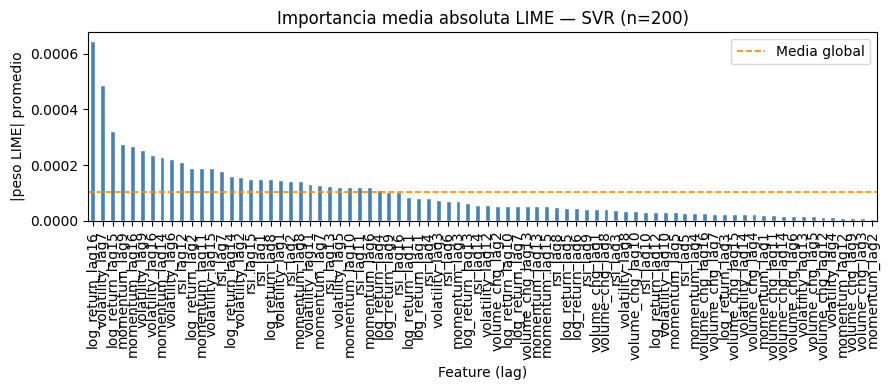

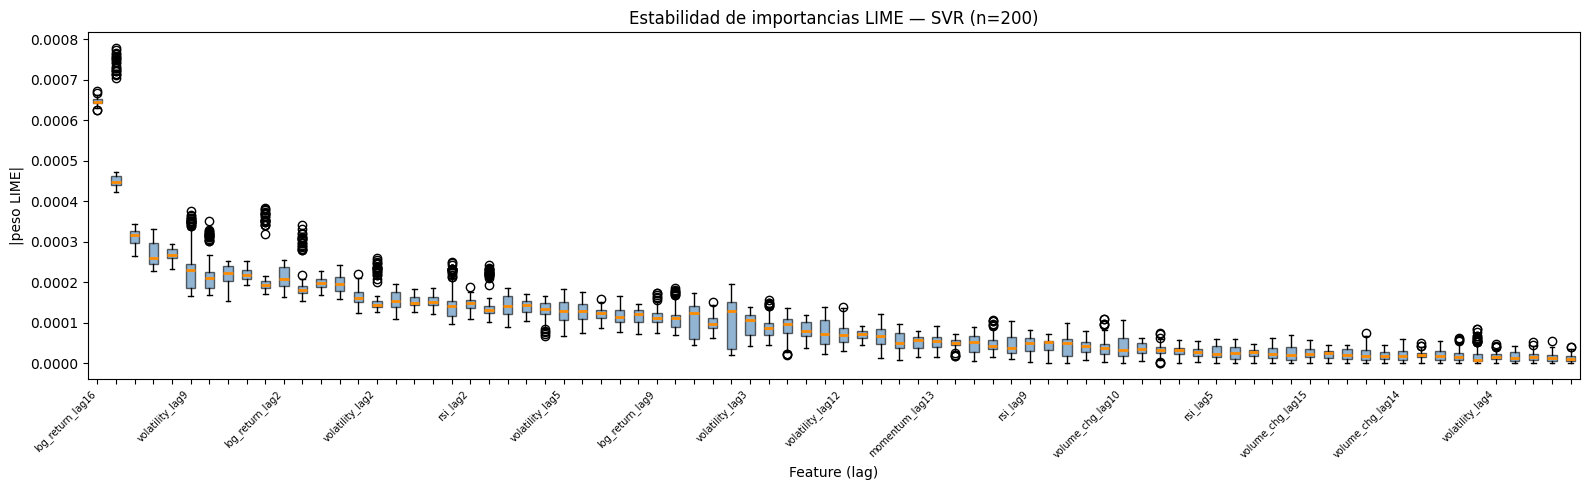

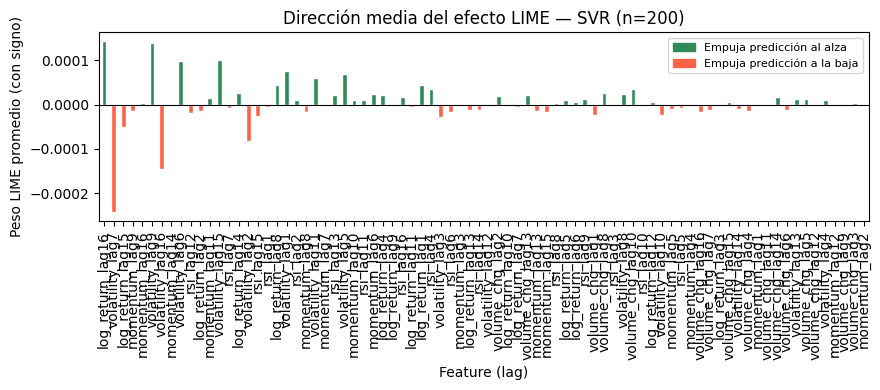

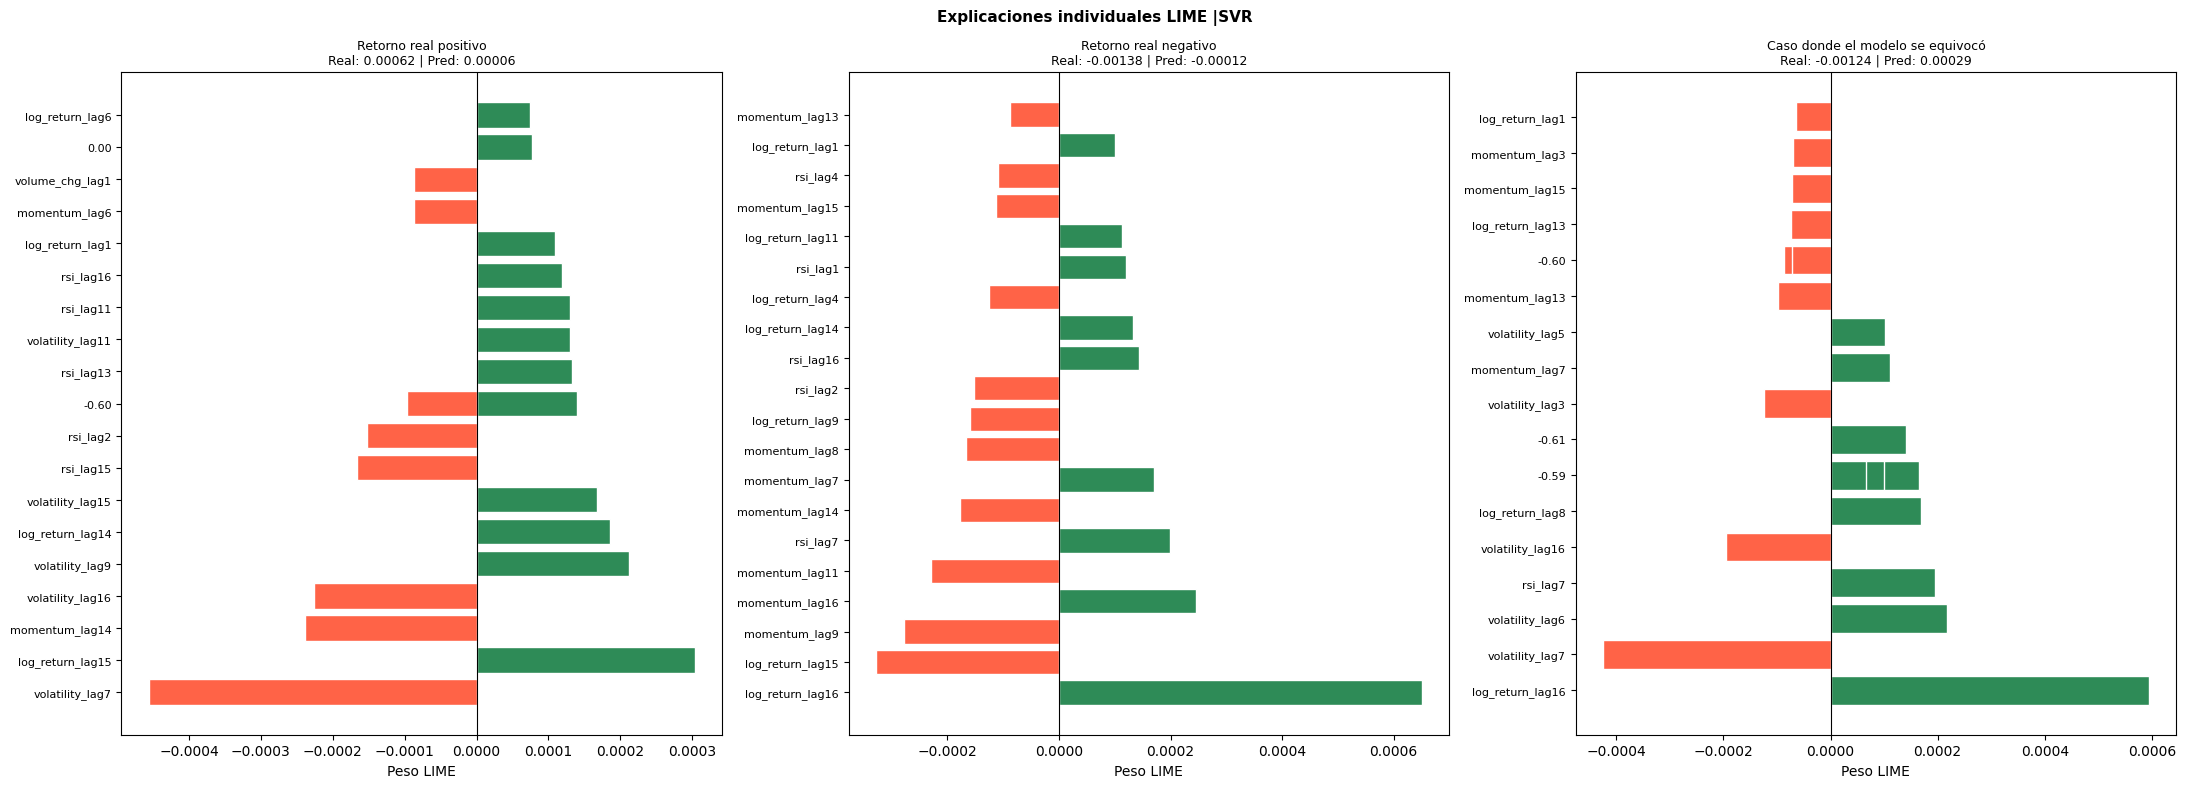

In [22]:
from IPython.display import display

# Identificar mejor modelo ML (excluye ARIMA porque no usa features tabulares)
modelos_ml = {k: v for k, v in modelos.items() if k != 'ARIMA'}

mejor_ml = min(
    [(nombre, metodo, res[nombre]['rmse'])
     for nombre in modelos_ml.keys()
     for metodo, res in [('Grid',   resultados_grid),
                         ('Random', resultados_random),
                         ('Optuna', resultados_optuna),
                         ('DEAP',   resultados_deap)]],
    key=lambda x: x[2]
)
nombre_lime     = mejor_ml[0]
ModelClass_lime = modelos_ml[nombre_lime]

if mejor_ml[1] == 'Grid':
    params_lime = resultados_grid[nombre_lime]['params']
elif mejor_ml[1] == 'Random':
    params_lime = resultados_random[nombre_lime]['params']
elif mejor_ml[1] == 'Optuna':
    params_lime = resultados_optuna[nombre_lime]['params']
else:
    params_lime = resultados_deap[nombre_lime]['params']

print(f'Modelo para LIME: {nombre_lime} ({mejor_ml[1]}) — RMSE: {mejor_ml[2]:.5f}')

# Entrenar sobre el último fold
fold_lime   = len(X) - 1
X_train_raw = X[fold_lime].reshape(X[fold_lime].shape[0], -1)
X_test_raw  = Xtest[fold_lime].reshape(Xtest[fold_lime].shape[0], -1)
y_train_raw = y[fold_lime][:, 0, 0].reshape(-1, 1)
y_test_raw  = ytest[fold_lime][:, 0, 0].ravel()

scaler_x_lime = StandardScaler().fit(X_train_raw)
scaler_y_lime = StandardScaler().fit(y_train_raw)

X_train_lime = scaler_x_lime.transform(X_train_raw)
X_test_lime  = scaler_x_lime.transform(X_test_raw)
y_train_lime = scaler_y_lime.transform(y_train_raw).ravel()

try:
    model_lime = ModelClass_lime(**params_lime, random_state=RANDOM_SEED)
except Exception:
    model_lime = ModelClass_lime(**params_lime)

model_lime.fit(X_train_lime, y_train_lime)

# Nombres de features para ventana multivariada: feature_col x lag
feature_names = [f'{col}_lag{lag+1}' for lag in range(N_LAGS)
                 for col in feature_cols]

def predict_fn(X_scaled):
    return scaler_y_lime.inverse_transform(
        model_lime.predict(X_scaled).reshape(-1, 1)
    ).ravel()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_lime,
    feature_names = feature_names,
    mode          = 'regression',
    random_state  = RANDOM_SEED
)

# ─────────────────────────────────────────────────────────────────────────────
# Importancia media + signo
# ─────────────────────────────────────────────────────────────────────────────
N_LIME = min(200, X_test_lime.shape[0])

importancias_abs = {f: [] for f in feature_names}
importancias_raw = {f: [] for f in feature_names}   # con signo

# ── LIME: explicaciones en paralelo (threads — LIME es thread-safe) ─────
def _lime_explain(i):
    exp = explainer.explain_instance(
        X_test_lime[i], predict_fn, num_features=len(feature_names)
    )
    return exp.as_list()

lime_results = Parallel(n_jobs=N_JOBS, backend='loky')(
    delayed(_lime_explain)(i) for i in range(N_LIME)
)

for feat_weights in lime_results:
    for feat, weight in feat_weights:
        feat_name = feat.split(' ')[0].split('>')[0].split('<')[0].strip()
        if feat_name in importancias_abs:
            importancias_abs[feat_name].append(abs(weight))
            importancias_raw[feat_name].append(weight)

imp_media = pd.Series(
    {f: np.mean(v) if v else 0.0 for f, v in importancias_abs.items()}
).sort_values(ascending=False)

imp_signed = pd.Series(
    {f: np.mean(v) if v else 0.0 for f, v in importancias_raw.items()}
)

print(f'\nImportancia media absoluta (LIME, n={N_LIME}):')
print(imp_media.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# Figura 1 — Importancia media absoluta (barras)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
imp_media.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Importancia media absoluta LIME — {nombre_lime} (n={N_LIME})')
ax.set_xlabel('Feature (lag)')
ax.set_ylabel('|peso LIME| promedio')
ax.axhline(imp_media.mean(), color='darkorange', linestyle='--',
           linewidth=1.2, label='Media global')
ax.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figura 2 — Distribución de pesos por lag (boxplot — estabilidad)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color='darkorange', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)

labels = list(imp_media.index)
tick_labels = [l if i % 5 == 0 else '' for i, l in enumerate(labels)]
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)

ax.set_title(f'Estabilidad de importancias LIME — {nombre_lime} (n={N_LIME})')
ax.set_xlabel('Feature (lag)')
ax.set_ylabel('|peso LIME|')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figura 3 — Dirección media del efecto por lag (signed weights)
# ─────────────────────────────────────────────────────────────────────────────
imp_signed_sorted = imp_signed[imp_media.index]
colors = ['seagreen' if v >= 0 else 'tomato' for v in imp_signed_sorted]

fig, ax = plt.subplots(figsize=(9, 4))
imp_signed_sorted.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'Dirección media del efecto LIME — {nombre_lime} (n={N_LIME})')
ax.set_xlabel('Feature (lag)')
ax.set_ylabel('Peso LIME promedio (con signo)')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='seagreen', label='Empuja predicción al alza'),
    plt.Rectangle((0,0),1,1, color='tomato',   label='Empuja predicción a la baja')
], fontsize=8)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figura 4 — Explicaciones individuales: 3 casos concretos
# caso positivo real, caso negativo real, caso donde el modelo se equivocó
# ─────────────────────────────────────────────────────────────────────────────
preds_test = predict_fn(X_test_lime)

# Índices de los 3 casos
idx_pos   = np.where(y_test_raw > 0)[0][0]          # retorno real positivo
idx_neg   = np.where(y_test_raw < 0)[0][0]          # retorno real negativo
# equivocado: signo predicho ≠ signo real
wrong_mask = np.sign(preds_test) != np.sign(y_test_raw)
idx_wrong  = np.where(wrong_mask)[0][0] if wrong_mask.any() else idx_pos

casos = [
    (idx_pos,   'Retorno real positivo'),
    (idx_neg,   'Retorno real negativo'),
    (idx_wrong, 'Caso donde el modelo se equivocó'),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

TOP_N = 20  # mostrar solo las 20 más importantes por caso

for ax, (idx, titulo) in zip(axes, casos):
    exp_caso = explainer.explain_instance(
        X_test_lime[idx], predict_fn, num_features=len(feature_names)
    )
    vals  = exp_caso.as_list()
    feats = [v[0].split(' ')[0].split('>')[0].split('<')[0].strip() for v in vals]
    pesos = [v[1] for v in vals]

    # ✅ Ordenar por importancia absoluta y tomar top N
    sorted_pairs = sorted(zip(feats, pesos), key=lambda x: abs(x[1]), reverse=True)[:TOP_N]
    feats_top  = [p[0] for p in sorted_pairs]
    pesos_top  = [p[1] for p in sorted_pairs]
    colores_caso = ['seagreen' if p >= 0 else 'tomato' for p in pesos_top]

    ax.barh(feats_top, pesos_top, color=colores_caso, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(
        f'{titulo}\nReal: {y_test_raw[idx]:.5f} | Pred: {preds_test[idx]:.5f}',
        fontsize=9
    )
    ax.set_xlabel('Peso LIME')
    ax.tick_params(axis='y', labelsize=8)  

plt.suptitle(f'Explicaciones individuales LIME |{nombre_lime}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Exportar métricas LIME como CSV
# ─────────────────────────────────────────────────────────────────────────────
df_lime = pd.DataFrame({
    'feature'           : imp_media.index,
    'importancia_media' : imp_media.values,
    'peso_signed'       : imp_signed[imp_media.index].values,
    'modelo'            : nombre_lime,
    'metodo_optimo'     : mejor_ml[1],
    'n_instancias'      : N_LIME
})
lime_csv_path = 'outputs/lime_metricas.csv'
df_lime.to_csv(lime_csv_path, index=False)

#### Interpretabilidad del modelo Lasso mediante LIME

Para el análisis de interpretabilidad se seleccionó el modelo Lasso optimizado con Bayesian Optimization debido a que obtuvo uno de los mejores desempeños generales durante las pruebas realizadas, alcanzando un RMSE cercano a 0.00270. Además de presentar métricas competitivas, este modelo mantiene una estructura lineal que facilita la interpretación de las contribuciones individuales de cada variable temporal mediante LIME.

El análisis de importancia media absoluta mostró que `lag_7` fue la variable más influyente dentro del modelo, alcanzando un peso promedio aproximado de 0.001215. Este resultado indica que la información correspondiente a siete periodos anteriores tuvo la mayor contribución sobre las predicciones de retornos del Bitcoin. En comparación, variables como `lag_6`, `lag_4` y `lag_3` presentaron importancias considerablemente menores, mientras que `lag_1` y `lag_5` tuvieron una influencia prácticamente marginal dentro del modelo.

En la gráfica de estabilidad de importancias se observa que `lag_7` mantiene una distribución bastante consistente entre las distintas observaciones analizadas. La baja dispersión de sus pesos evidencia que el modelo utiliza esta variable de forma estable y recurrente para generar predicciones. Por otro lado, los demás lags presentan una mayor variabilidad y menor magnitud, indicando que su influencia depende más del comportamiento específico de cada ventana temporal.

La gráfica de dirección media del efecto permitió identificar si cada lag empuja las predicciones hacia retornos positivos o negativos. En este caso, `lag_7` presentó un efecto promedio negativo relativamente fuerte, lo que sugiere que incrementos en esta variable suelen asociarse con una disminución en la predicción futura del retorno. De manera similar, `lag_6`, `lag_3`, `lag_1` y `lag_5` también mostraron contribuciones promedio negativas. En contraste, `lag_4` y `lag_2` presentaron efectos positivos pequeños, contribuyendo ligeramente a incrementar las predicciones del modelo.

Las explicaciones individuales generadas con LIME evidencian cómo el modelo toma decisiones distintas dependiendo de cada observación analizada. En el caso donde el retorno real fue positivo, el modelo asignó un peso positivo dominante a uno de los lags principales, mientras que las demás variables aportaron efectos negativos de menor magnitud. Para el ejemplo de retorno negativo, la mayoría de variables empujaron la predicción hacia valores negativos, especialmente `lag_6`, mostrando coherencia con el comportamiento observado en la serie real.

Finalmente, en el caso donde el modelo cometió un error de predicción, se observó un conflicto entre variables con efectos positivos y negativos. Aunque algunas variables impulsaron la predicción hacia retornos positivos, el efecto negativo dominante generado por otros lags llevó al modelo a estimar un retorno negativo cuando el valor real fue positivo. Esto demuestra que, aunque el modelo Lasso logra identificar patrones temporales relevantes, todavía existen movimientos altamente volátiles y no lineales del mercado del Bitcoin que resultan difíciles de capturar completamente.

### Exportación de predicciones para comparación con modelo híbrido

Se exportan las predicciones del mejor modelo benchmark para el test de Diebold-Mariano cruzado con el modelo SVR+XGBoost+Ridge.

In [23]:
# ── Exportar predicciones del mejor benchmark para DM cruzado ────────────
import os
os.makedirs('outputs', exist_ok=True)

# df_final ya está ordenado por RMSE (test) ascendente
mejor_benchmark = df_final.iloc[0]['Modelo']
mejor_metodo_bm = df_final.iloc[0]['Método Optim.']

preds_mejor_bm = preds_por_modelo_res[mejor_benchmark]
real_bm        = real_comun_res

np.save('outputs/benchmark_best_preds.npy', preds_mejor_bm)
np.save('outputs/benchmark_real.npy',       real_bm)

# ── Salvar predicciones de TODOS los modelos ──────────────────────────────
for nombre in modelos.keys():
    np.save(f'outputs/preds_{nombre.replace(" ", "_")}.npy',
            preds_por_modelo_res[nombre])

np.save('outputs/real_comun.npy', real_comun_res)

# ── Salvar params óptimos ─────────────────────────────────────────────────
import joblib
joblib.dump(mejor_por_modelo,  'outputs/mejores_params.joblib')
joblib.dump(metodo_por_modelo, 'outputs/metodos_seleccionados.joblib')

# ── Salvar tablas comparativas ────────────────────────────────────────────
df_final.to_csv('outputs/metricas_finales_test.csv', index=False)
df_boot.to_csv('outputs/bootstrap_metricas.csv', index=False)
df_dm.to_csv('outputs/diebold_mariano.csv', index=False)

# ── Info del experimento ──────────────────────────────────────────────────
import json as _json
config = {
    'N_LAGS'      : N_LAGS,
    'N_STEPS'     : N_STEPS,
    'N_JUMP'      : N_JUMP,
    'RANDOM_SEED' : RANDOM_SEED,
    'feature_cols': feature_cols,
    'modelos'     : list(modelos.keys()),
    'mejor_bm'    : mejor_benchmark,
    'metodo_bm'   : mejor_metodo_bm,
    'rmse_bm'     : float(df_final.iloc[0]['RMSE (test)']),
    'mae_bm'      : float(df_final.iloc[0]['MAE (test)']),
}
with open('outputs/config_experimento.json', 'w') as f:
    _json.dump(config, f, indent=2)

print(f'Mejor benchmark exportado: {mejor_benchmark} ({mejor_metodo_bm})')
print(f'Shape preds: {preds_mejor_bm.shape} | Shape real: {real_bm.shape}')
print(f'\nOutputs guardados:')
print(f'  outputs/benchmark_best_preds.npy')
print(f'  outputs/benchmark_real.npy')
print(f'  outputs/real_comun.npy')
for nombre in modelos.keys():
    print(f'  outputs/preds_{nombre.replace(" ", "_")}.npy')
print(f'  outputs/mejores_params.joblib')
print(f'  outputs/metodos_seleccionados.joblib')
print(f'  outputs/metricas_finales_test.csv')
print(f'  outputs/bootstrap_metricas.csv')
print(f'  outputs/diebold_mariano.csv')
print(f'  outputs/config_experimento.json')


Mejor benchmark exportado: Random Forest (Bayesiana)
Shape preds: (25041,) | Shape real: (25041,)

Outputs guardados:
  outputs/benchmark_best_preds.npy
  outputs/benchmark_real.npy
  outputs/real_comun.npy
  outputs/preds_KNN.npy
  outputs/preds_Ridge.npy
  outputs/preds_Lasso.npy
  outputs/preds_Decision_Tree.npy
  outputs/preds_Random_Forest.npy
  outputs/preds_XGBoost.npy
  outputs/preds_SVR.npy
  outputs/preds_ARIMA.npy
  outputs/mejores_params.joblib
  outputs/metodos_seleccionados.joblib
  outputs/metricas_finales_test.csv
  outputs/bootstrap_metricas.csv
  outputs/diebold_mariano.csv
  outputs/config_experimento.json
